In [1]:
import matplotlib.pyplot as plt
import numpy as np

import wandb

# Global cluster configuration mappings (used across all plots)
MARKER_POOL = {"2": "*", "4": "X", "8": "D", "16": "^"}

# Color intensity mapping for blue/red shaded plots
CLUSTER_COLOR_MAP = {
    "2": 0.2,  # Lightest shade
    "4": 0.4,  # Light-medium shade
    "8": 0.55,  # Medium-dark shade
    "16": 0.7,  # Darkest shade
}

DATASET_ORDER = {"HAR": 0, "FEMNIST": 1, "CIFAR10": 2, "CIFAR10_dir0.1": 3}

# Direct color mapping for single-color plots (using viridis positions)
CLUSTER_DIRECT_COLOR_MAP = CLUSTER_COLOR_MAP

# Dataset to model mapping
DATASET_MODEL_MAP = {"HAR": "HarBox - CNN", "FEMNIST": "FEMNIST - MobileNet", "CIFAR10": "CIFAR-10 - ResNet18", "CIFAR10_dir0.1": "CIFAR-10 (α=0.1) - ResNet18"}

In [2]:
# Initialize wandb API
api = wandb.Api(timeout=120)

# # Get the sweep
# sweep = api.sweep("saul0/fedHAR/5nf0ajkn")

# # Get all runs from the sweep
# runs = sweep.runs

# # Print parameters for each run
# for run in runs:
#     print(f"Run: {run.name} (ID: {run.id})")
#     print(f"Config: {run.config}")
#     print("-" * 80)

In [3]:
# === Helpers for the CIFAR-dir0.1 extension + comparison table ===
# (new runs live under entity s-urso2; consensus/prune are encoded in the run NAME,
#  CommCost groups are 0-indexed, and multi-key scan_history returns nothing -> scan one key per call.)
import os, re, pickle
import pandas as pd

_DIR01_CACHE_PATH = "wandb_dir01_cache.pkl"
_dir01_cache = {}
if os.path.exists(_DIR01_CACHE_PATH):
    with open(_DIR01_CACHE_PATH, "rb") as _f:
        _dir01_cache = pickle.load(_f)

def _dir01_save_cache():
    with open(_DIR01_CACHE_PATH, "wb") as _f:
        pickle.dump(_dir01_cache, _f, protocol=pickle.HIGHEST_PROTOCOL)

_COMASK_GRID_RE = re.compile(
    r"comask_(\d+)clust.*?consensus_percentage=([0-9.]+).*?prune_percent=([0-9.]+)")

def parse_comask_grid_name(name):
    """Parse cluster_size / consensus_percentage / prune_percent from a comask_clust_grid run name."""
    m = _COMASK_GRID_RE.search(name)
    if not m:
        return None
    return {"cluster_size": int(m.group(1)),
            "consensus_percentage": float(m.group(2)),
            "prune_percent": float(m.group(3))}

def final_acc_metrics(run):
    """Personalized + Global final accuracy from run.summary.
    Personalized = Personal/Test/Acc (CoMask/PACFL) else Test/Acc (FedAvg/SCAFFOLD/Hermes)."""
    s = run.summary
    def g(k):
        v = s.get(k)
        return float(v) if isinstance(v, (int, float)) else None
    personal = g("Personal/Test/Acc")
    test = g("Test/Acc")
    return {"personalized": personal if personal is not None else test,
            "global": g("Server/Test/Acc")}

def run_cost_and_pruning(run, n_groups):
    """Total upload cost (MB), final Server/Test/Acc, and pruning events for a CoMask run."""
    ck = ("dir01_hist", run.id)
    if ck in _dir01_cache:
        return _dir01_cache[ck]
    acc = [r["Server/Test/Acc"] for r in run.scan_history(keys=["Server/Test/Acc"])
           if r.get("Server/Test/Acc") is not None and r["Server/Test/Acc"] == r["Server/Test/Acc"]]
    server_accuracy = acc[-1] if acc else None
    total_cost = 0.0
    for i in range(n_groups):
        k = f"CommCost/Group_{i}/Total/Combined"
        for row in run.scan_history(keys=[k]):
            v = row.get(k)
            if v is not None and v == v:
                total_cost += v
    total_cost_mb = total_cost / (8 * 1024 * 1024)
    group_sizes, pruning_events = {}, []
    for i in range(n_groups):
        k = f"CommCost/Group_{i}/ModelSize/Parameters"
        for row in run.scan_history(keys=[k, "round"]):
            rnd, ms = row.get("round"), row.get(k)
            if rnd is None or ms is None or ms != ms:
                continue
            if i in group_sizes and ms < group_sizes[i][-1][1]:
                pruning_events.append({"round": rnd, "group_id": i,
                                       "model_size_before": group_sizes[i][-1][1],
                                       "model_size_after": ms})
            group_sizes.setdefault(i, []).append((rnd, ms))
    out = {"total_cost_mb": total_cost_mb, "server_accuracy": server_accuracy,
           "pruning_events": pruning_events}
    _dir01_cache[ck] = out
    _dir01_save_cache()
    return out

# CIFAR-dir0.1 FedAvg baseline (computed from s-urso2/FedCIFAR10 fedavg_dir0.1_cifar): cost MB / global acc
FEDAVG_DIR01_BASELINE_COST_MB = 426619.80
FEDAVG_DIR01_BASELINE_ACC = 0.336
print("dir0.1 helpers ready")


dir0.1 helpers ready


# Plots for RQ4 (cost model)

In [3]:
# Collect communication cost data from the sweep
# sweep_id = "ICDCS/FedHAR/9uw01ajn"

# sweep_id = "ICDCS/FedHAR/7sim29aw"

sweep_id = "ICDCS/FedCIFAR10/laogimbc"

print(f"Fetching sweep: {sweep_id}")
sweep = api.sweep(sweep_id)
runs = sweep.runs

# Dictionary to store run data
run_comm_costs = {}

for run in runs:
    print(f"\nProcessing run: {run.name}")

    # Initialize data structures
    rounds = []
    round_totals = {}  # {round_num: total_cost} - to accumulate costs per round across clusters
    cluster_costs = {}  # {cluster_id: [costs per round]}
    cluster_model_sizes = {}  # {cluster_id: set of unique model sizes in bits}

    # Build list of keys to fetch for up to 16 groups
    group_cost_keys = [f"CommCost/Group_{i}/Total/Combined" for i in range(16)]
    group_size_keys = [f"CommCost/Group_{i}/ModelSize/Bits" for i in range(16)]

    for i, (key_cost, key_size) in enumerate(zip(group_cost_keys, group_size_keys)):
        for row in run.scan_history(keys=["round", key_cost, key_size]):
            round_num = row["round"]
            if round_num is None:
                continue

            if round_num not in rounds:
                rounds.append(round_num)

            # Collect costs and model sizes for each cluster (up to 16)
            cost_val = row[key_cost]

            if cost_val is not None and cost_val == cost_val:  # Check for not None and not NaN
                # Accumulate cost for this round
                if round_num not in round_totals:
                    round_totals[round_num] = 0
                round_totals[round_num] += cost_val

                if i not in cluster_costs:
                    cluster_costs[i] = []
                cluster_costs[i].append(cost_val)
            else:
                if i not in cluster_costs:
                    cluster_costs[i] = []
                cluster_costs[i].append(0)

            # Collect model size in bits for each cluster

            model_size_val = row[key_size]
            if model_size_val is not None and model_size_val == model_size_val:
                if i not in cluster_model_sizes:
                    cluster_model_sizes[i] = set()
                cluster_model_sizes[i].add(model_size_val)

    # Convert round_totals dict to list ordered by rounds
    total_costs_per_round = [round_totals.get(r, 0) for r in sorted(rounds)]

    # Calculate average pruning ratio for this run
    pruning_ratios = []
    for cluster_id, sizes in cluster_model_sizes.items():
        unique_sizes = sorted(sizes)
        # Ratio of smaller to larger model size
        ratio = unique_sizes[0] / unique_sizes[-1]
        pruning_ratios.append(ratio)
        print(f"  Cluster {cluster_id}: sizes={unique_sizes}, ratio={ratio:.4f}")

    avg_ratio = np.mean(pruning_ratios)
    avg_pruning_ratio = 1 - avg_ratio
    print(f"  Average pruning ratio: {avg_pruning_ratio:.4f}")

    # Store the data
    run_comm_costs[run.name] = {
        "rounds": sorted(rounds),
        "total_costs": total_costs_per_round,
        "cluster_costs": cluster_costs,
        "cluster_model_sizes": {k: sorted(v) for k, v in cluster_model_sizes.items()},
        "avg_pruning_ratio": avg_pruning_ratio,
    }

    print(f"  Collected {len(rounds)} rounds")
    print(f"  Total clusters: {len(cluster_costs)}")

print(f"\nCollected data from {len(run_comm_costs)} runs")

Fetching sweep: ICDCS/FedCIFAR10/laogimbc

Processing run: 8-clust
  Cluster 0: sizes=[200046112.0, 369278048.0], ratio=0.5417
  Cluster 1: sizes=[200046112.0, 369278048.0], ratio=0.5417
  Cluster 2: sizes=[200167744.0, 369278048.0], ratio=0.5421
  Cluster 3: sizes=[200046112.0, 369278048.0], ratio=0.5417
  Cluster 4: sizes=[200046112.0, 369278048.0], ratio=0.5417
  Cluster 5: sizes=[200046112.0, 369278048.0], ratio=0.5417
  Cluster 6: sizes=[200167744.0, 369278048.0], ratio=0.5421
  Average pruning ratio: 0.4582
  Collected 300 rounds
  Total clusters: 7

Processing run: 4-clust
  Cluster 0: sizes=[200046112.0, 369278048.0], ratio=0.5417
  Cluster 1: sizes=[200046112.0, 369278048.0], ratio=0.5417
  Cluster 2: sizes=[200046112.0, 369278048.0], ratio=0.5417
  Cluster 3: sizes=[200167744.0, 369278048.0], ratio=0.5421
  Average pruning ratio: 0.4582
  Collected 300 rounds
  Total clusters: 4

Processing run: 2-clust
  Cluster 0: sizes=[200046112.0, 369278048.0], ratio=0.5417
  Cluster 1: 

In [ ]:
# parameters
total_clients = 120
num_clients = 10
z_card = np.array([57, 63], dtype=float)
# size in bits
model_size = 487648
prune_ratio = 0.33
# need to see based on the votes
p = [1 / 50, 1 / 80]

# vectorized computations with numpy
s_z = (z_card / total_clients) * num_clients
extr_prob = np.divide(s_z, z_card, out=np.zeros_like(s_z))

# compute p_z and protect against non-positive probabilities
p_z = 1.0 - (1.0 - extr_prob * p) ** z_card

t_before = 1.0 / p_z
q_z = 1.0 - prune_ratio


def cost_model(t):
    return 2 * s_z * model_size * (np.minimum(t_before, t) + q_z * np.maximum(0, t - t_before))


In [ ]:
# parameters
total_clients = 100
num_clients = 10
z_card = np.array([18, 22, 20, 40], dtype=float)
# size in bits
model_size = 2954224384.0 / 8
prune_ratio = 0.4579
# need to see based on the votes
p = [1 / 10]

# vectorized computations with numpy
s_z = (z_card / total_clients) * num_clients
extr_prob = np.divide(s_z, z_card, out=np.zeros_like(s_z))

# compute p_z and protect against non-positive probabilities
p_z = 1.0 - (1.0 - extr_prob * p) ** z_card

t_before = 1.0 / p_z
q_z = 1.0 - prune_ratio


def cost_model(t):
    return 2 * s_z * model_size * (np.minimum(t_before, t) + q_z * np.maximum(0, t - t_before))


In [17]:
t_before

array([6.04279854, 5.04109982, 5.49169741, 3.02089029])

Testing cost_model function...
t_before values: [6.04279854 5.04109982 5.49169741 3.02089029]
s_z values: [1.8 2.2 2.  4. ]
model_size: 369278048.0

Test outputs:
  t=0: cost=[0. 0. 0. 0.]
  t=50: cost=[3.97118625e+10 4.77914503e+10 4.37515435e+10 8.41607291e+10]
  t=100: cost=[7.57452758e+10 9.18322889e+10 8.37886695e+10 1.64234981e+11]
  t=150: cost=[1.11778689e+11 1.35873127e+11 1.23825795e+11 2.44309233e+11]
  t=200: cost=[1.47812103e+11 1.79913966e+11 1.63862921e+11 3.24383485e+11]


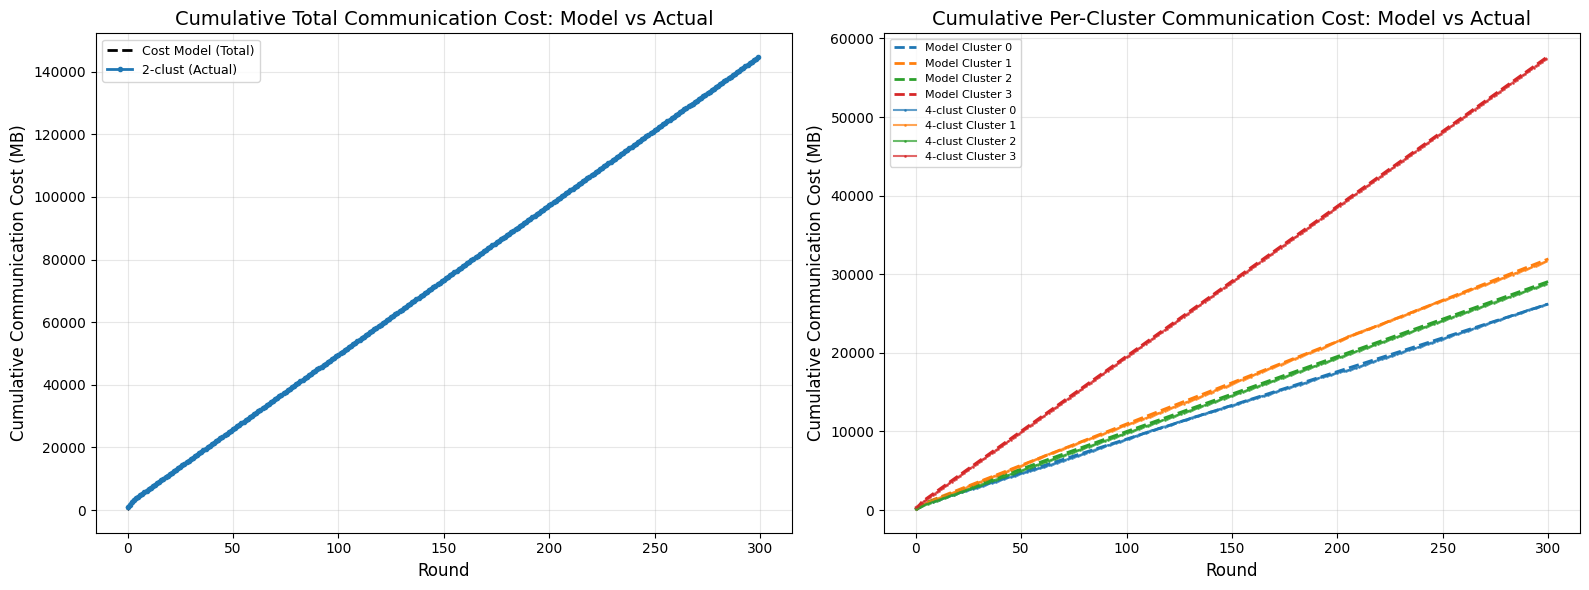


Plot generated successfully!
t_before thresholds: [6.04279854 5.04109982 5.49169741 3.02089029]


In [18]:
# Test and plot the cost model over time
print("Testing cost_model function...")
print(f"t_before values: {t_before}")
print(f"s_z values: {s_z}")
print(f"model_size: {model_size}")

# Test with a few sample values
test_times = [0, 50, 100, 150, 200]
print("\nTest outputs:")
for t in test_times:
    try:
        cost = cost_model(t)
        print(f"  t={t}: cost={cost}")
    except Exception as e:
        print(f"  t={t}: ERROR - {e}")

# Create time array for plotting the model
t_values = np.linspace(0, 300, 300)
model_costs = np.array([cost_model(t) for t in t_values])

# Convert model costs to MB (model already returns cumulative values)
model_costs_mb = model_costs / (8 * 1024 * 1024)

# Create figure with subplots: one for total cost, one for per-cluster costs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Total Communication Cost (CUMULATIVE)
ax1.set_xlabel("Round", fontsize=12)
ax1.set_ylabel("Cumulative Communication Cost (MB)", fontsize=12)
ax1.set_title("Cumulative Total Communication Cost: Model vs Actual", fontsize=14)

# Plot model cumulative total cost (sum across groups) - already cumulative from model
total_model_cost = model_costs_mb.sum(axis=1)
ax1.plot(t_values, total_model_cost, label="Cost Model (Total)", linewidth=2, linestyle="--", color="black")

# Plot actual run total costs (CUMULATIVE)
for run_name, run_data in run_comm_costs.items():
    if "2-clust" not in run_name:
        continue
    rounds = run_data["rounds"]
    total_costs = np.cumsum(run_data["total_costs"]) / (8 * 1024 * 1024)  # Cumulative and convert to MB
    ax1.plot(rounds, total_costs, label=f"{run_name} (Actual)", linewidth=2, marker="o", markersize=3)

ax1.legend(loc="best", fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Per-Cluster Communication Cost (CUMULATIVE)
ax2.set_xlabel("Round", fontsize=12)
ax2.set_ylabel("Cumulative Communication Cost (MB)", fontsize=12)
ax2.set_title("Cumulative Per-Cluster Communication Cost: Model vs Actual", fontsize=14)

# Plot model cumulative costs per group - already cumulative from model
for i in range(len(z_card)):
    ax2.plot(t_values, model_costs_mb[:, i], label=f"Model Cluster {i}", linewidth=2, linestyle="--")

# Plot actual cluster costs from runs (CUMULATIVE)
colors = plt.cm.tab10(np.linspace(0, 1, 10))
for run_name, run_data in run_comm_costs.items():
    if "4-clust" not in run_name:
        continue
    rounds = run_data["rounds"]
    cluster_costs = run_data["cluster_costs"]

    for cluster_id, costs in cluster_costs.items():
        cumulative_costs = np.cumsum(costs) / (8 * 1024 * 1024)  # Cumulative and convert to MB
        if (cumulative_costs == 0).all():
            continue
        ax2.plot(
            rounds,
            cumulative_costs[:300],
            label=f"{run_name} Cluster {cluster_id}",
            linewidth=1.5,
            marker=".",
            markersize=2,
            color=colors[cluster_id % 10],
            alpha=0.7,
        )

ax2.legend(loc="best", fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nPlot generated successfully!")
print(f"t_before thresholds: {t_before}")

# RQ3 answer

In [4]:
runs_history_cache = {}

In [5]:
other_runs_history_cache = runs_history_cache

In [6]:
runs_history_cache.update(other_runs_history_cache)

In [7]:
# Process multiple sweeps and compute metrics for each run
# Define three separate lists for each dataset

# FEMNIST sweeps
sweep_ids_femnist = [
    "ICDCS/FEMNIST/5pv184vp",
    "ICDCS/FEMNIST/r2gq4nge",
    "ICDCS/FEMNIST/wj8b8txc",
    "ICDCS/FEMNIST/m21qv60k",
    "ICDCS/FEMNIST/zhmp23re", 
    "ICDCS/FEMNIST/l0iddhdn", 
]

# CIFAR10 sweeps
sweep_ids_cifar = [
    "ICDCS/FedCIFAR10/5dc8bowz",
    "ICDCS/FedCIFAR10/f89m606t",
    "ICDCS/FedCIFAR10/gbt8maur",
    "ICDCS/FedCIFAR10/wj72wuag",
]

# HAR sweeps
sweep_ids_har = [
    "ICDCS/FedHAR/b74scpxu",
    "ICDCS/FedHAR/x4lfn7y2",
    "ICDCS/FedHAR/pbs8l2ut",
    "ICDCS/FedHAR/09gwsk62",
]

# Combine all sweeps with dataset labels
all_datasets = [("FEMNIST", sweep_ids_femnist), ("CIFAR10", sweep_ids_cifar), ("HAR", sweep_ids_har)]

metric_name = "Server/Test/Acc"

# Dictionary to store results by dataset
results_by_dataset = {}

print("=" * 80)
print("Processing sweeps for all datasets")
print(f"Metric: {metric_name}")
print("=" * 80)

for dataset_name, sweep_ids in all_datasets:
    print(f"\n{'=' * 80}")
    print(f"Dataset: {dataset_name}")
    print(f"{'=' * 80}")

    results_dict = {}

    for sweep_id in sweep_ids:
        print(f"\nSweep: {sweep_id}")
        print("-" * 80)

        # Get the sweep
        sweep = api.sweep(sweep_id)
        sweep_runs = sweep.runs

        for run in sweep_runs:
            # Get prune_percent from config
            print(run.config)
            prune_percent = run.config["train_args"].get("prune_percent",0.1)

            # Compute the metric (last value)
            cache_key = (run.id, metric_name)

            cache_key_cost = (run.id, "total_upload_cost_sum")
            if cache_key in runs_history_cache:
                metric_data = runs_history_cache[cache_key]
                total_cost_mb = runs_history_cache[cache_key_cost]
            else:
                metric_data = []
                total_cost = 0

                # Build list of keys to fetch
                group_keys = [f"CommCost/Group_{i}/Total/Combined" for i in range(16)]
                all_keys = [metric_name] + group_keys

                for key in all_keys:
                    for row in run.scan_history(keys=[key]):
                        val = row[key]
                        if "CommCost" not in key:
                            metric_data.append(val)
                        else:
                            total_cost += val

                runs_history_cache[cache_key_cost] = total_cost
                runs_history_cache[cache_key] = metric_data
                # Convert to MB
                total_cost_mb = total_cost / (8 * 1024 * 1024) if total_cost is not None else None

            server_accuracy = metric_data[-1] if metric_data else None

            # Check for consensus_percentage in config
            consensus_percentage = run.config["train_args"].get("consensus_percentage", None)
            if consensus_percentage is not None and consensus_percentage != 0.5:
                print(f"Excluding run due to consensus_percentage={consensus_percentage}")
                continue

            # Store in dictionary
            results_dict[run.name] = {
                "prune_percent": prune_percent,
                "server_accuracy": server_accuracy,
                "total_cost_mb": total_cost_mb,
                "consensus_percentage": consensus_percentage,
            }

            # Print the triplet
            print(f"Run: {run.name}")
            print(
                f"  <prune_percent={prune_percent}, {metric_name}={server_accuracy:.4f}, total_cost={total_cost_mb:.2f} MB>"
            )
            print()

    print(f"\n{dataset_name} - Results stored")
    print(f"Total runs processed: {len(results_dict)}")

    # Store results for this dataset
    results_by_dataset[dataset_name] = results_dict

print("\n" + "=" * 80)
print("All datasets processed")
print(f"Datasets: {list(results_by_dataset.keys())}")
print("=" * 80)

Processing sweeps for all datasets
Metric: Server/Test/Acc

Dataset: FEMNIST

Sweep: ICDCS/FEMNIST/5pv184vp
--------------------------------------------------------------------------------
{'train_args': {'pruning': 'proposal', 'preference': -200, 'prune_percent': 0.25, 'ssl_coefficient': 0.0001, 'accuracy_threshold': 0.4, 'consolidation_percentage': 0.25}, 'device_args': {'gpu_id': 0}, 'cluster_0_num_clients': 722, 'cluster_1_num_clients': 744, 'cluster_2_num_clients': 821, 'cluster_3_num_clients': 713}
Run: 4-clust-4
  <prune_percent=0.25, Server/Test/Acc=0.8080, total_cost=149558.73 MB>

{'train_args': {'pruning': 'proposal', 'preference': -200, 'prune_percent': 0.2, 'ssl_coefficient': 0.0001, 'accuracy_threshold': 0.4, 'consolidation_percentage': 0.2}, 'device_args': {'gpu_id': 0}, 'cluster_0_num_clients': 722, 'cluster_1_num_clients': 744, 'cluster_2_num_clients': 821, 'cluster_3_num_clients': 713}
Run: 4-clust-3
  <prune_percent=0.2, Server/Test/Acc=0.8166, total_cost=172627.00 M

In [8]:
# === RQ3: add CIFAR-dir0.1 prune-percentage data (consensus=0.5, vary prune) ===
# Source: s-urso2/comask_clust_grid. Stored under synthetic keys "<k>-clust-comask01-<id>"
# so the existing plot cell's name parsing (parts[0]=cluster size) works unchanged.
results_by_dataset.setdefault("CIFAR10_dir0.1", {})
_DIR01_RQ3_CONSENSUS = 0.5
_grid = [(_r, parse_comask_grid_name(_r.name)) for _r in api.runs("s-urso2/comask_clust_grid")
         if _r.state == "finished"]
for _r, _info in _grid:
    if _info is None or abs(_info["consensus_percentage"] - _DIR01_RQ3_CONSENSUS) > 1e-9:
        continue
    _c = _info["cluster_size"]
    _m = run_cost_and_pruning(_r, _c)
    results_by_dataset["CIFAR10_dir0.1"][f"{_c}-clust-comask01-{_r.id}"] = {
        "prune_percent": _info["prune_percent"],
        "server_accuracy": _m["server_accuracy"],
        # RQ3 plot cells (13/14) express the existing datasets' cost in BITS (cell-12
        # cache path skips the /8/1024/1024), so match that convention here:
        "total_cost_mb": _m["total_cost_mb"] * 8 * 1024 * 1024,
        "consensus_percentage": _DIR01_RQ3_CONSENSUS,
    }
print("CIFAR10_dir0.1 RQ3 runs added:", len(results_by_dataset["CIFAR10_dir0.1"]))


CIFAR10_dir0.1 RQ3 runs added: 15


HAR
2-clust
[15, 30, 30, 45, 60, 75]
[80.21729230036547, 63.60550766699424, 64.79501787814883, 46.39997647594764, 33.73881019377349, 12.424761344166448]
4-clust
[15, 30, 30, 45, 60, 75]
[79.62714246027271, 63.526998106942486, 63.526998106942486, 44.429865906352525, 31.133492579117632, 8.993613272176036]
8-clust
[15, 30, 30, 45, 60, 75]
[79.73487502323262, 64.05664817094599, 64.05664817094599, 44.591798095521014, 31.36489669129488, 9.265673653022063]
FEMNIST
16-clust
[15, 30, 45, 60, 75]
[80.13974763103391, 64.11901576709684, 55.41752877130538, 47.60857953003457, 40.76018646274187]
4-clust
[15, 30, 45, 60, 75]
[81.46459056400037, 65.89244116941602, 54.39214684138022, 45.74049342539828, 39.62815675541325]
8-clust
[15, 30, 45, 60, 75]
[80.730432776187, 63.423466666990116, 54.367978477884, 45.785945185355445, 39.19594678742534]
CIFAR10
2-clust
[15, 45, 60, 75]
[86.01560903350891, 31.65022597991147, 18.100556426904028, 11.277735666158337]
4-clust
[15, 30, 45, 60, 75]
[85.91256641720743, 57.

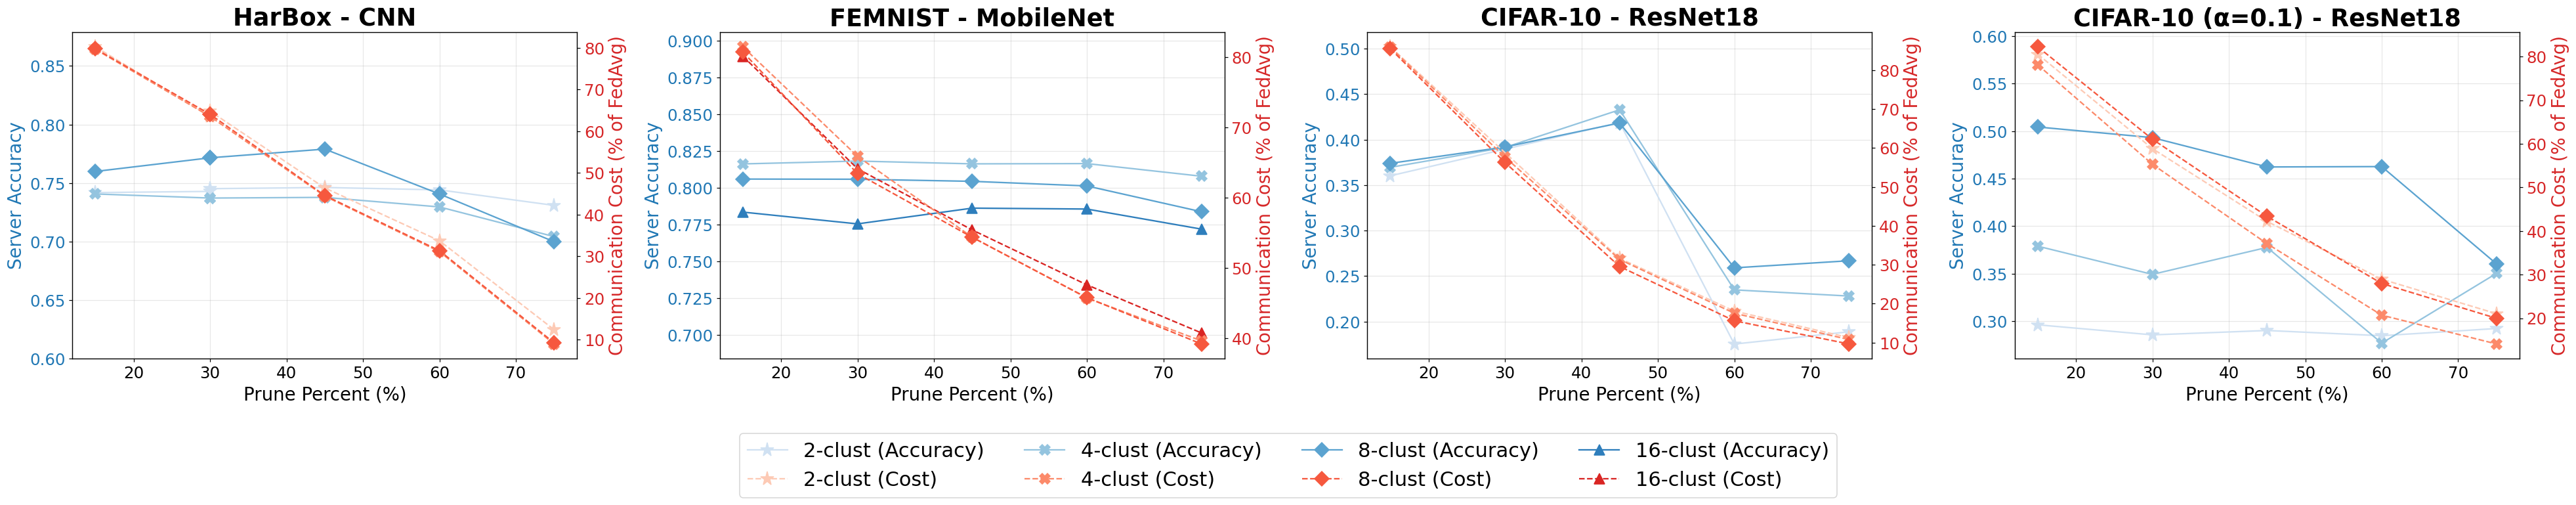

In [ ]:
# Increase font sizes for all plot elements
plt.rcParams.update(
    {
        "font.size": 18,
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 17,
        "figure.titlesize": 22,
        "legend.title_fontsize": 17,
    }
)

# Group runs by cluster prefix for each dataset and create 3 subplots
from collections import defaultdict

# Create figure with 3 subplots (one per dataset)
n_ds = len(results_by_dataset)
fig, axes = plt.subplots(1, n_ds, figsize=(9 * n_ds, 6))
axes = np.atleast_1d(axes)

# Store all unique cluster configurations across all datasets for shared legend
all_cluster_configs = set()
legend_items = {}  # {cluster_size: (line1, line2, label_acc, label_cost)}

# First pass: Calculate FedAvg baseline costs for each dataset
fedavg_baseline_costs = {
    "FEMNIST": 377405.2047729492,
    "HAR": 582.4843597412109,
    "CIFAR10": 427473.03634643555,
    "CIFAR10_dir0.1": 426619.80,
}

# Process each dataset

for ax_idx, (dataset_name, results_dict) in enumerate(
    sorted(results_by_dataset.items(), key=lambda x: DATASET_ORDER[x[0]])
):
    ax1 = axes[ax_idx]

    # Get FedAvg baseline for this dataset (fallback to 1 if not found to avoid division by zero)
    fedavg_cost = fedavg_baseline_costs[dataset_name]

    # Group runs by cluster prefix
    cluster_runs = defaultdict(list)

    for run_name, data in results_dict.items():
        # Extract the cluster prefix (e.g., "2_clust" from "2_clust_random_0.1")
        # Assuming format: <N>_clust<something> or <N>-clust<something>
        if "clust" in run_name:
            # Handle both "-" and "_" separators
            parts = run_name.replace("_", "-").split("-")
            cluster_size = parts[0]

            if dataset_name == "FEMNIST" and data["prune_percent"] == 0.1:
                cluster_size = str(int(cluster_size))

            if cluster_size in MARKER_POOL:
                prefix = f"{cluster_size}-clust"
                all_cluster_configs.add(cluster_size)

                cluster_runs[prefix].append(
                    {
                        "run_name": run_name,
                        "prune_percent": data["prune_percent"],
                        "server_accuracy": data["server_accuracy"],
                        "total_cost_mb": data["total_cost_mb"],
                        "cluster_size": cluster_size,
                    }
                )

    # Sort each cluster's runs by prune_percent
    for prefix in cluster_runs:
        cluster_runs[prefix].sort(key=lambda x: x["prune_percent"])

    # Left y-axis for accuracy
    ax1.set_xlabel("Prune Percent (%)", fontsize=18)
    ax1.set_ylabel("Server Accuracy", color="tab:blue", fontsize=18)
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    # Right y-axis for communication cost (as percentage of FedAvg)
    ax2 = ax1.twinx()
    ax2.set_ylabel("Communication Cost (% of FedAvg)", color="tab:red", fontsize=18)
    ax2.tick_params(axis="y", labelcolor="tab:red")

    print(dataset_name)
    # Plot each cluster run
    for prefix, runs in sorted(cluster_runs.items()):
        if not runs:
            continue

        print(prefix)

        prune_percents = [round(r["prune_percent"] * 3 * 100) for r in runs]  # Convert to percentage
        print(prune_percents)
        # Remove duplicates by converting to a set and back to a list
        accuracies = [r["server_accuracy"] for r in runs]
        # Convert costs to percentage of FedAvg baseline
        costs = [(r["total_cost_mb"] / (fedavg_cost * 8 * 1024 * 1024)) * 100 for r in runs]

        # Extract cluster size
        cluster_size = runs[0]["cluster_size"]

        # Get consistent color based on cluster size using global mapping
        color_intensity = CLUSTER_COLOR_MAP[cluster_size]
        accuracy_color = plt.cm.Blues(color_intensity)
        cost_color = plt.cm.Reds(color_intensity)

        marker = MARKER_POOL[cluster_size]
        markersize = 14 if marker == "*" else 10

        # Plot accuracy on left y-axis
        line1 = ax1.plot(
            prune_percents,
            accuracies,
            marker=marker,
            linestyle="-",
            color=accuracy_color,
            label=f"{cluster_size}-clust (Accuracy)",
            markersize=markersize,
        )[0]

        ax1.set_ylim(
            min(accuracies) - 0.1,
            max(accuracies) + 0.1,
        )

        # Plot communication cost on right y-axis (as percentage)
        print(costs)
        line2 = ax2.plot(
            prune_percents,
            costs,
            marker=marker,
            linestyle="--",
            color=cost_color,
            label=f"{cluster_size}-clust (Cost)",
            markersize=markersize,
        )[0]

        # Store legend items for this cluster size (only once across all datasets)
        if cluster_size not in legend_items:
            legend_items[cluster_size] = (
                line1,
                line2,
                f"{cluster_size}-clust (Accuracy)",
                f"{cluster_size}-clust (Cost)",
            )

    # Add grid
    ax1.grid(True, alpha=0.3)

    # Set subplot title
    ax1.set_title(f"{DATASET_MODEL_MAP[dataset_name]}", fontsize=24, fontweight="bold")

# Create a shared legend with all cluster configurations (sorted by cluster size)
all_lines = []
all_labels = []
for cluster_size in sorted(legend_items.keys(), key=int):
    line1, line2, label1, label2 = legend_items[cluster_size]
    all_lines.extend([line1, line2])
    all_labels.extend([label1, label2])

fig.legend(all_lines, all_labels, loc="lower center", ncols=4, fontsize=20, bbox_to_anchor=(0.5, -0.2))

# Overall title
# fig.suptitle(
#     "Server Accuracy and Communication Cost vs Prune Percent by Cluster Configuration",
#     fontsize=28,
#     fontweight="bold",
# )

plt.tight_layout()
plt.show()

print("\nCreated 3-subplot figure with shared legend containing all cluster configurations")
print(f"FedAvg baselines used: {fedavg_baseline_costs}")


HAR - 2-clust: 6 runs plotted
  2-clust-1: prune%=15.0, ratio=1.1184
  2-clust-vote-3: prune%=30.0, ratio=1.4124
  2-clust-2: prune%=30.0, ratio=1.3908
  2-clust-3: prune%=45.0, ratio=1.9449
  2-clust-4: prune%=60.0, ratio=2.6674
  2-clust-5: prune%=75.0, ratio=7.1142

HAR - 4-clust: 6 runs plotted
  4-clust-1: prune%=15.0, ratio=1.1249
  4-clust-vote-3: prune%=30.0, ratio=1.4033
  4-clust-2: prune%=30.0, ratio=1.4033
  4-clust-3: prune%=45.0, ratio=2.0081
  4-clust-4: prune%=60.0, ratio=2.8340
  4-clust-5: prune%=75.0, ratio=9.4698

HAR - 8-clust: 6 runs plotted
  8-clust-1: prune%=15.0, ratio=1.1525
  8-clust-vote-3: prune%=30.0, ratio=1.4566
  8-clust-2: prune%=30.0, ratio=1.4566
  8-clust-3: prune%=45.0, ratio=2.1126
  8-clust-4: prune%=60.0, ratio=2.8558
  8-clust-5: prune%=75.0, ratio=9.1347

FEMNIST - 4-clust: 4 runs plotted
  4-clust-1: prune%=15.0, ratio=1.3646
  4-clust-2: prune%=45.0, ratio=2.0439
  4-clust-3: prune%=60.0, ratio=2.4311
  4-clust-4: prune%=75.0, ratio=2.7765

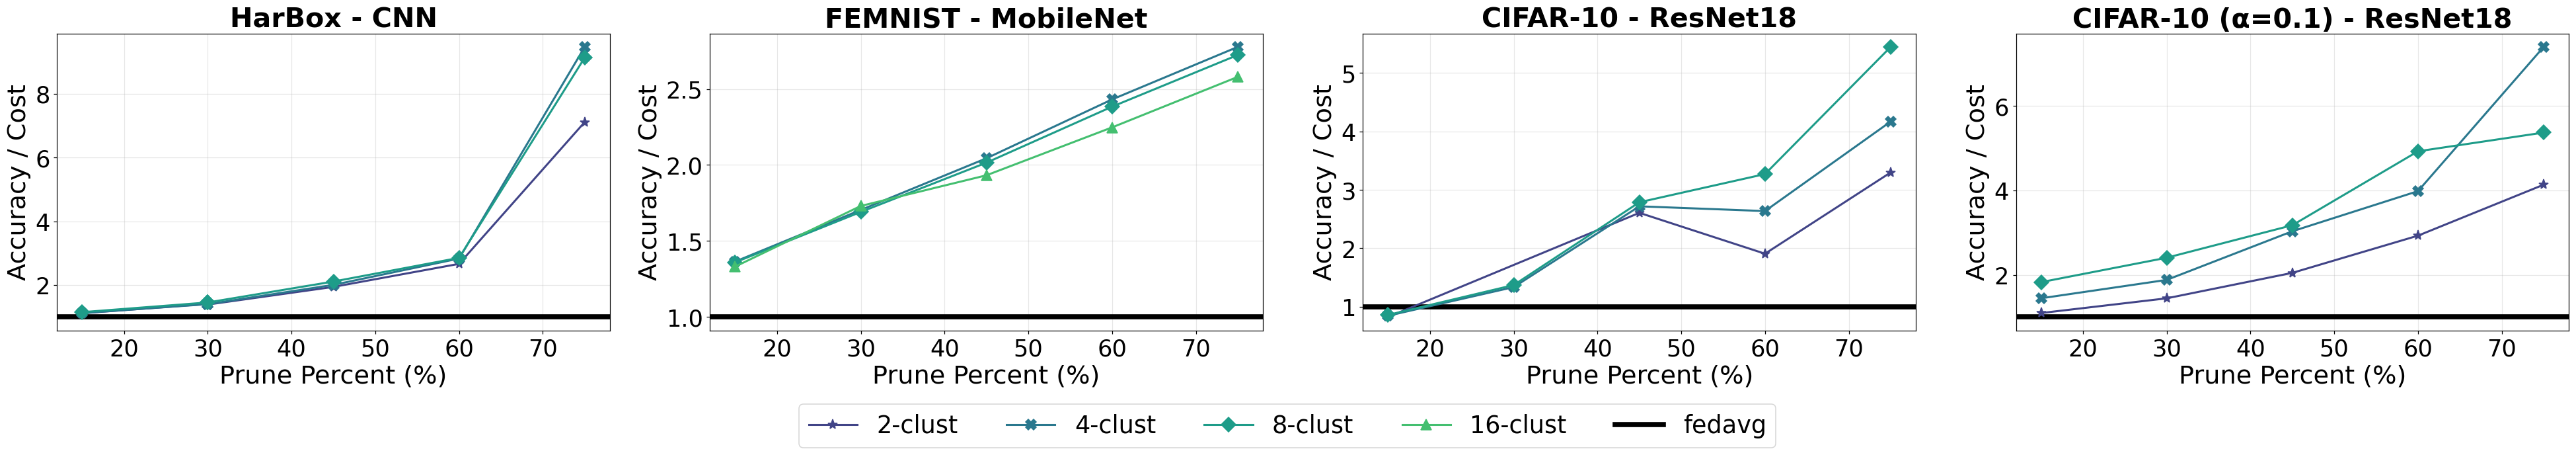

In [ ]:
# Plot Accuracy/Cost Ratio vs Prune Percent for each dataset
from collections import defaultdict

plt.close()

# Increase font sizes for all plot elements
plt.rcParams.update(
    {
        "font.size": 25,
        "axes.titlesize": 27,
        "axes.labelsize": 25,
        "xtick.labelsize": 23,
        "ytick.labelsize": 23,
        "legend.fontsize": 24,
        "figure.titlesize": 29,
        "legend.title_fontsize": 24,
    }
)

n_ds = len(results_by_dataset)
fig, axes = plt.subplots(1, n_ds, figsize=(9 * n_ds, 6))
axes = np.atleast_1d(axes)

# Store legend items for all cluster configurations
legend_items = {}  # {cluster_size: (line, label)}

fedavg_baseline_costs_rq2 = {
    "FEMNIST": 377405.2047729492,
    "HAR": 582.4843597412109,
    "CIFAR10": 427473.03634643555,
    "CIFAR10_dir0.1": 426619.80,
}

fedavg_baseline_acc_rq2 = {
    "CIFAR10": 0.5077,
    "FEMNIST": 0.7344,
    "HAR": 0.8269,
    "CIFAR10_dir0.1": 0.336,
}

# Use viridis colormap with fixed positions for all 4 cluster sizes
colors = plt.cm.viridis([CLUSTER_DIRECT_COLOR_MAP[k] for k in sorted(MARKER_POOL.keys(), key=int)])
color_map = {size: colors[i] for i, size in enumerate(sorted(MARKER_POOL.keys(), key=int))}

# Track global min and max ratios across all datasets
global_min_ratio = float("inf")
global_max_ratio = float("-inf")

for ax_idx, (dataset_name, results_dict) in enumerate(
    sorted(results_by_dataset.items(), key=lambda x: DATASET_ORDER[x[0]])
):
    ax = axes[ax_idx]

    fedavg_ratio = fedavg_baseline_acc_rq2[dataset_name] / fedavg_baseline_costs_rq2[dataset_name]

    c = fedavg_baseline_costs_rq2[dataset_name] / fedavg_baseline_acc_rq2[dataset_name]

    line_avg = ax.axhline(
        y=fedavg_ratio * c,
        label="fedavg",
        color="black",
        linewidth=5,
    )

    cluster_runs = defaultdict(list)

    for run_name, data in results_dict.items():
        # Extract cluster size from run name
        if "clust" in run_name:
            # Handle both "-" and "_" separators
            parts = run_name.replace("_", "-").split("-")
            cluster_size = parts[0]
            if dataset_name == "FEMNIST" and data["prune_percent"] == 0.1:
                cluster_size = str(2 * int(cluster_size))

            if cluster_size in MARKER_POOL:
                # Calculate accuracy/cost ratio
                accuracy = data["server_accuracy"]
                cost_mb = data["total_cost_mb"]

                # Convert to appropriate units (same as RQ3)
                if dataset_name != "HAR":
                    cost_gb = cost_mb / (8 * 1024 * 1024)
                    ratio = accuracy / cost_gb * c if cost_gb > 0 else 0
                    unit = "GB"
                else:
                    cost_mb = cost_mb / (8 * 1024 * 1024)
                    ratio = accuracy / cost_mb * c if cost_mb > 0 else 0
                    unit = "MB"

                # Track global min/max
                global_min_ratio = min(global_min_ratio, ratio)
                global_max_ratio = max(global_max_ratio, ratio)

                cluster_runs[cluster_size].append(
                    {
                        "run_name": run_name,
                        "prune_percent": data["prune_percent"],
                        "accuracy_cost_ratio": ratio,
                        "unit": unit,
                    }
                )

    # Sort each cluster's runs by prune_percent
    for cluster_size in cluster_runs:
        cluster_runs[cluster_size].sort(key=lambda x: x["prune_percent"])

    # Set up axis labels
    ax.set_xlabel("Prune Percent (%)")

    # Determine y-axis label based on first run's unit
    ax.set_ylabel("Accuracy / Cost")

    # Plot each cluster configuration
    for cluster_size in sorted(cluster_runs.keys(), key=int):
        runs = cluster_runs[cluster_size]

        if not runs:
            continue

        # Extract data
        prune_percents = [round(r["prune_percent"] * 3 * 100) for r in runs]  # Convert to percentage
        ratios = [r["accuracy_cost_ratio"] for r in runs]

        # Determine marker and color based on cluster size (using global mappings)
        marker = MARKER_POOL[cluster_size]
        color = color_map[cluster_size]

        # Plot ratio
        line = ax.plot(
            prune_percents,
            ratios,
            marker=marker,
            linestyle="-",
            color=color,
            label=f"{cluster_size}-clust",
            linewidth=2,
            markersize=10,
        )[0]

        # Store legend items for this cluster size (only once across all datasets)
        if cluster_size not in legend_items:
            legend_items[cluster_size] = (line, f"{cluster_size}-clust")

        print(f"\n{dataset_name} - {cluster_size}-clust: {len(runs)} runs plotted")
        for r in runs:
            print(f"  {r['run_name']}: prune%={r['prune_percent'] * 3 * 100:.1f}, ratio={r['accuracy_cost_ratio']:.4f}")

    # Add grid
    ax.grid(True, alpha=0.3)

    # Set subplot title
    ax.set_title(f"{DATASET_MODEL_MAP[dataset_name]}", fontweight="bold")

# Set consistent y-axis limits across all subplots with ±5% margin
y_margin = 0.05 * (global_max_ratio - global_min_ratio)
y_min = global_min_ratio - y_margin
y_max = global_max_ratio + y_margin

# for ax in axes:
#     ax.set_ylim(y_min, y_max)

# Create a shared legend with all cluster configurations (sorted by cluster size)
all_lines = []
all_labels = []
for cluster_size in sorted(legend_items.keys(), key=int):
    line, label = legend_items[cluster_size]
    all_lines.append(line)
    all_labels.append(label)

fig.legend(
    all_lines + [line_avg],
    all_labels + ["fedavg"],
    loc="lower center",
    ncols=5,
    bbox_to_anchor=(0.5, -0.1),
)

# # Overall title
# fig.suptitle(
#     "Accuracy/Cost Ratio vs Prune Percent by Cluster Configuration",
#     fontsize=28,
#     fontweight="bold",
# )

plt.tight_layout()
plt.show()

print("\nCreated 3-subplot figure with Accuracy/Cost ratio vs Prune Percent")
print(f"All cluster configurations in legend: {sorted(legend_items.keys(), key=int)}")

In [11]:
import pickle

# Filepath to save both variables
_SAVE_PATH = "runs_history-prune.pkl"

# Save variables to disk
with open(_SAVE_PATH, "wb") as f:
    pickle.dump(
        {
            "runs_history_cache": runs_history_cache,
        },
        f,
        protocol=pickle.HIGHEST_PROTOCOL,
    )


In [12]:
import pickle

# Filepath to save both variables
_SAVE_PATH = "runs_history-prune.pkl"

# --- Load back ---
with open(_SAVE_PATH, "rb") as f:
    _loaded = pickle.load(f)


runs_history_cache = _loaded["runs_history_cache"]

print(f"Loaded runs_history_cache ({len(runs_history_cache)} keys)from {_SAVE_PATH}")

Loaded runs_history_cache (152 keys)from runs_history-prune.pkl


In [13]:
# Add consensus_percentage to each run in results_dict
for run_name in results_dict:
    results_dict[run_name]["consensus_percentage"] = 0.5

print(f"Added consensus_percentage=0.5 to {len(results_dict)} runs")

Added consensus_percentage=0.5 to 15 runs


# RQ2: consensus percentage

In [14]:
# Fetch the run
run = api.run("ICDCS/FEMNIST/8j7nzp8z")  # Adjust project path as needed

print(f"Computing total communication cost for run: {run.name}")
print(f"Run ID: {run.id}")
print("-" * 80)

# Sum CommCost/Total/Combined across all steps
total_combined_cost = 0
step_count = 0
accuracy_values = []

# "CommCost/Total/Combined" ,
for row in run.scan_history(keys=["Server/Test/Acc"]):
    cost_val = row.get("CommCost/Total/Combined")
    if cost_val is not None and cost_val == cost_val:  # Check for not None and not NaN
        total_combined_cost += cost_val
        step_count += 1

    acc_val = row.get("Server/Test/Acc")
    if acc_val is not None and acc_val == acc_val:  # Check for not None and not NaN
        accuracy_values.append(acc_val)

# Convert to MB and GB
total_cost_mb = total_combined_cost / (8 * 1024 * 1024)
total_cost_gb = total_combined_cost / (8 * 1024 * 1024 * 1024)

print(f"\nTotal steps with cost data: {step_count}")
print("Total combined communication cost:")
print(f"  {total_combined_cost:.2f} bits")
print(f"  {total_cost_mb:.2f} MB")
print(f"  {total_cost_gb:.4f} GB")

# Print final accuracy
if accuracy_values:
    final_accuracy = accuracy_values[-1]
    print(f"\nFinal Server/Test/Acc: {final_accuracy:.4f}")
else:
    print("\nNo Server/Test/Acc data found")


Computing total communication cost for run: fedavg.-best
Run ID: 8j7nzp8z
--------------------------------------------------------------------------------

Total steps with cost data: 0
Total combined communication cost:
  0.00 bits
  0.00 MB
  0.0000 GB

Final Server/Test/Acc: 0.8269


In [15]:
import pickle

# Filepath to save both variables
_SAVE_PATH = "runs_history_and_results_rq2.pkl"

# Save variables to disk
with open(_SAVE_PATH, "wb") as f:
    pickle.dump(
        {
            "runs_history_cache": runs_history_cache,
            "results_by_dataset_rq2": results_by_dataset_rq2,
        },
        f,
        protocol=pickle.HIGHEST_PROTOCOL,
    )

print(
    f"Saved runs_history_cache ({len(runs_history_cache)} keys) and results_by_dataset_rq2 "
    f"({sum(len(v) for v in results_by_dataset_rq2.values())} runs) -> {_SAVE_PATH}"
)


NameError: name 'results_by_dataset_rq2' is not defined

In [ ]:
import pickle

# Filepath to save both variables
_SAVE_PATH = "runs_history_and_results_rq2.pkl"

# --- Load back ---
with open(_SAVE_PATH, "rb") as f:
    _loaded = pickle.load(f)

# Reassign to the same variable names (overwrites current in-memory objects)
runs_history_cache = _loaded["runs_history_cache"]
results_by_dataset_rq2 = _loaded["results_by_dataset_rq2"]

print(
    f"Loaded runs_history_cache ({len(runs_history_cache)} keys) and results_by_dataset_rq2 "
    f"({sum(len(v) for v in results_by_dataset_rq2.values())} runs) from {_SAVE_PATH}"
)

Loaded runs_history_cache (78 keys) and results_by_dataset_rq2 (39 runs) from runs_history_and_results_rq2.pkl


In [ ]:
runs_history_cache.keys()

dict_keys([('y4bbf3y4', 'Server/Test/Acc'), ('y4bbf3y4', 'total_upload_cost_sum'), ('46mt7ppa', 'Server/Test/Acc'), ('46mt7ppa', 'total_upload_cost_sum'), ('5uu55cei', 'Server/Test/Acc'), ('5uu55cei', 'total_upload_cost_sum'), ('gzk3ufcb', 'Server/Test/Acc'), ('gzk3ufcb', 'total_upload_cost_sum'), ('o1l6x8s8', 'Server/Test/Acc'), ('o1l6x8s8', 'total_upload_cost_sum'), ('6nq32ex2', 'Server/Test/Acc'), ('6nq32ex2', 'total_upload_cost_sum'), ('np6aq66d', 'Server/Test/Acc'), ('np6aq66d', 'total_upload_cost_sum'), ('145qv068', 'Server/Test/Acc'), ('145qv068', 'total_upload_cost_sum'), ('367owevs', 'Server/Test/Acc'), ('367owevs', 'total_upload_cost_sum'), ('p0k34hj2', 'Server/Test/Acc'), ('p0k34hj2', 'total_upload_cost_sum'), ('p1zb0nqk', 'Server/Test/Acc'), ('p1zb0nqk', 'total_upload_cost_sum'), ('1zmh3id7', 'Server/Test/Acc'), ('1zmh3id7', 'total_upload_cost_sum'), ('sqi29l01', 'Server/Test/Acc'), ('sqi29l01', 'total_upload_cost_sum'), ('x9h7k6ov', 'Server/Test/Acc'), ('x9h7k6ov', 'total_

In [ ]:
runs_history_cache = {}
results_by_dataset_rq2 = {"FEMNIST": {}, "CIFAR10": {}, "HAR": {}}

In [ ]:
# Process multiple sweeps and compute metrics for each run

# Define sweep IDs for each dataset
sweep_ids_by_dataset = {
    "FEMNIST": ["ICDCS/FEMNIST/m21qv60k","ICDCS/FEMNIST/zhmp23re", "ICDCS/FEMNIST/l0iddhdn", ],
    "CIFAR10": ["ICDCS/FedCIFAR10/5dc8bowz", "ICDCS/FedCIFAR10/5jx8ivoz"],
    "HAR": ["ICDCS/FedHAR/b74scpxu", "ICDCS/FedHAR/svi499n1"],
}

# Metric to extract (can be changed)
metric_name = "Server/Test/Acc"

print("=" * 80)
print("Processing sweeps for all datasets (RQ2)")
print(f"Metric: {metric_name}")
print("=" * 80)

for dataset_name, sweep_ids in sweep_ids_by_dataset.items():
    print(f"\n{'=' * 80}")
    print(f"Dataset: {dataset_name}")
    print(f"{'=' * 80}")

    for sweep_id in sweep_ids:
        print(f"\nSweep: {sweep_id}")
        print("-" * 80)

        # Get the sweep
        sweep = api.sweep(sweep_id)
        sweep_runs = sweep.runs

        for run in sweep_runs:
            # Get consensus_percent from config
            print(run.config)
            consensus_percent = run.config["train_args"].get("consensus_percentage",0)

            # Compute the metric (last value)
            cache_key = (run.id, metric_name)
            if cache_key in runs_history_cache:
                metric_data = runs_history_cache[cache_key]
            else:
                metric_data = []
                for row in run.scan_history(keys=[metric_name]):
                    val = row[metric_name]
                    if val is not None and val == val:  # Check for not None and not NaN
                        metric_data.append(val)
                runs_history_cache[cache_key] = metric_data

            server_accuracy = metric_data[-1] if metric_data else None

            # Compute total communication cost
            # For FedAvg, use download metric; for others, sum group uploads

            cache_key = (run.id, "total_upload_cost_sum")
            if cache_key in runs_history_cache:
                total_cost = runs_history_cache[cache_key]
            else:
                # Build list of keys to fetch for up to 16 groups
                group_keys = [f"CommCost/Group_{i}/Total/Combined" for i in range(16)]

                total_cost = 0
                for key in group_keys:
                    for row in run.scan_history(keys=[key]):
                        # Sum all available group costs for this row
                        val = row[key]
                        if val is not None and val == val:
                            total_cost += val
                runs_history_cache[cache_key] = total_cost

            # Convert to MB
            total_cost_mb = total_cost / (8 * 1024 * 1024) if total_cost is not None else None

            # Detect pruning rounds by monitoring model size decreases
            pruning_events = []  # List of (round, group_id, model_size_before, model_size_after)

            # Track model size for each group across rounds
            group_model_sizes = {}  # {group_id: [(round, model_size), ...]}

            # Build list of keys to fetch for up to 16 groups
            model_size_keys = [f"CommCost/Group_{i}/ModelSize/Parameters" for i in range(16)]
            model_size_keys.append("round")

            for i in range(16):
                metric_key = f"CommCost/Group_{i}/ModelSize/Parameters"

                for row in run.scan_history(keys=[metric_key, "round"]):
                    round_num = row["round"]
                    assert round_num is not None

                    model_size = row[metric_key]
                    if model_size is not None and model_size == model_size:  # Check for not None and not NaN
                        if i not in group_model_sizes:
                            group_model_sizes[i] = []

                        # Check if this is a decrease from previous round
                        if group_model_sizes[i]:
                            prev_round, prev_size = group_model_sizes[i][-1]
                            if model_size < prev_size:
                                # Pruning detected!
                                pruning_events.append(
                                    {
                                        "round": round_num,
                                        "group_id": i,
                                        "model_size_before": prev_size,
                                        "model_size_after": model_size,
                                    }
                                )

                        group_model_sizes[i].append((round_num, model_size))

            # Store in dictionary for this dataset
            results_by_dataset_rq2[dataset_name][run.name] = {
                "consensus_percentage": consensus_percent,
                "server_accuracy": server_accuracy,
                "total_cost_mb": total_cost_mb,
                "pruning_events": pruning_events,
            }

            # Print the triplet
            print(f"Run: {run.name}")
            print(
                f"  <consensus_percentage={consensus_percent}, {metric_name}={server_accuracy:.4f}, total_cost={total_cost_mb:.2f} MB>"
            )

            # Print pruning events
            if pruning_events:
                print(f"  Pruning events detected: {len(pruning_events)}")
                for event in pruning_events:
                    print(
                        f"    Round {event['round']}: Group {event['group_id']} pruned "
                        f"({event['model_size_before']:.0f} -> {event['model_size_after']:.0f} parameters)"
                    )
            else:
                print("  No pruning events detected")
            print()

    print(f"\n{dataset_name} - Results stored")
    print(f"Total runs processed: {len(results_by_dataset_rq2[dataset_name])}")

print("\n" + "=" * 80)
print("All datasets processed")
print(f"Datasets: {list(results_by_dataset_rq2.keys())}")
print("=" * 80)

Processing sweeps for all datasets (RQ2)
Metric: Server/Test/Acc

Dataset: FEMNIST

Sweep: ICDCS/FEMNIST/m21qv60k
--------------------------------------------------------------------------------
{'train_args': {'learning_rate': 0.1}, 'device_args': {'gpu_id': 1}}
Run: fedavg.-best
  <consensus_percentage=0, Server/Test/Acc=0.8269, total_cost=0.00 MB>
  No pruning events detected


Sweep: ICDCS/FEMNIST/zhmp23re
--------------------------------------------------------------------------------
{'train_args': {'pruning': 'proposal', 'preference': -90, 'prune_percent': 0.1, 'ssl_coefficient': 0.0001, 'accuracy_threshold': 0.1, 'consensus_percentage': 0.7, 'consolidation_percentage': 0.1}, 'device_args': {'gpu_id': 0}, 'cluster_0_num_clients': 483, 'cluster_1_num_clients': 450, 'cluster_2_num_clients': 395, 'cluster_3_num_clients': 288, 'cluster_4_num_clients': 455, 'cluster_5_num_clients': 382, 'cluster_6_num_clients': 305, 'cluster_7_num_clients': 242}
Run: 8-clust-vote-4
  <consensus_perce

In [ ]:
# === RQ2: add CIFAR-dir0.1 consensus data (prune=0.1, vary consensus) ===
# Source: s-urso2/comask_clust_grid. Synthetic keys include "vote" so the existing
# consensus plot cells (which require "vote" in the name) pick these up unchanged.
results_by_dataset_rq2.setdefault("CIFAR10_dir0.1", {})
_DIR01_RQ2_PRUNE = 0.1
_grid = [(_r, parse_comask_grid_name(_r.name)) for _r in api.runs("s-urso2/comask_clust_grid")
         if _r.state == "finished"]
for _r, _info in _grid:
    if _info is None or abs(_info["prune_percent"] - _DIR01_RQ2_PRUNE) > 1e-9:
        continue
    _c = _info["cluster_size"]
    _m = run_cost_and_pruning(_r, _c)
    results_by_dataset_rq2["CIFAR10_dir0.1"][f"{_c}-clust-vote-comask01-{_r.id}"] = {
        "consensus_percentage": _info["consensus_percentage"],
        "server_accuracy": _m["server_accuracy"],
        "total_cost_mb": _m["total_cost_mb"],
        "pruning_events": _m["pruning_events"],
    }
print("CIFAR10_dir0.1 RQ2 runs added:", len(results_by_dataset_rq2["CIFAR10_dir0.1"]))



HAR - 2-clust: 4 runs plotted
  2-clust-vote-1: consensus=0.1, acc=0.7351, cost=62.5% of FedAvg
  2-clust-vote-2-best: consensus=0.3, acc=0.7434, cost=62.9% of FedAvg
  2-clust-vote-3: consensus=0.5, acc=0.7429, cost=63.6% of FedAvg
  2-clust-vote-4: consensus=0.7, acc=0.7434, cost=64.4% of FedAvg

HAR - 4-clust: 4 runs plotted
  4-clust-vote-1: consensus=0.1, acc=0.7487, cost=62.4% of FedAvg
  4-clust-vote-2-best: consensus=0.3, acc=0.7506, cost=62.9% of FedAvg
  4-clust-vote-3: consensus=0.5, acc=0.7372, cost=63.5% of FedAvg
  4-clust-vote-4: consensus=0.7, acc=0.7328, cost=64.4% of FedAvg

HAR - 8-clust: 4 runs plotted
  8-clust-vote-1: consensus=0.1, acc=0.7700, cost=62.4% of FedAvg
  8-clust-vote-2-best: consensus=0.3, acc=0.7727, cost=63.3% of FedAvg
  8-clust-vote-3: consensus=0.5, acc=0.7716, cost=64.1% of FedAvg
  8-clust-vote-4: consensus=0.7, acc=0.7635, cost=64.6% of FedAvg

FEMNIST - 4-clust: 4 runs plotted
  4-clust-vote-1: consensus=0.1, acc=0.8022, cost=51.6% of FedAvg

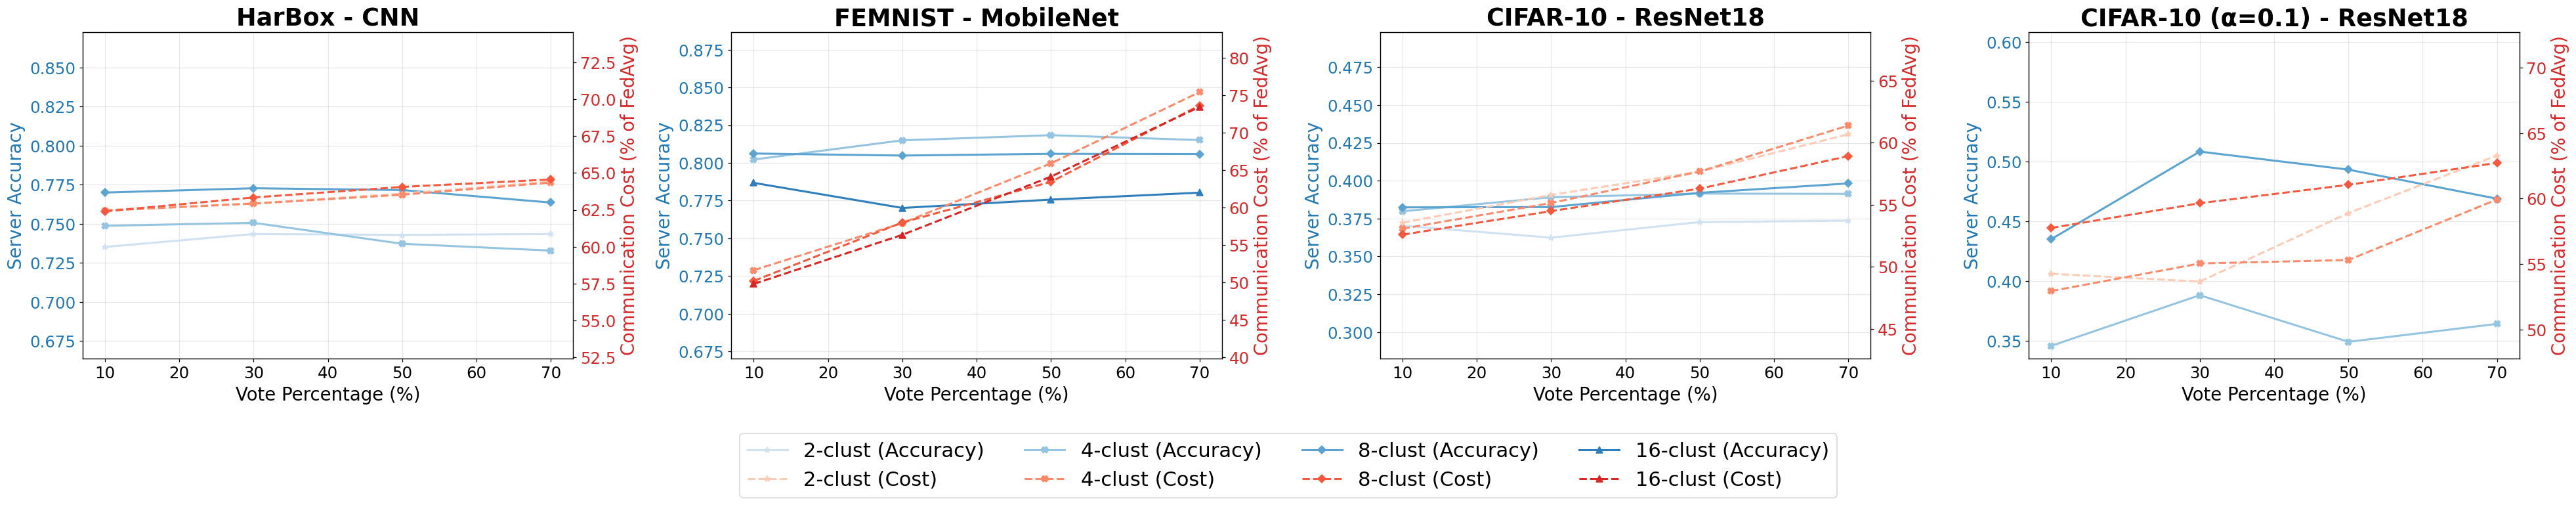

In [ ]:
# Group runs by cluster size for consensus percentage analysis
# Create figure with 3 subplots (one per dataset)
from collections import defaultdict

plt.close()

# Increase font sizes for all plot elements
plt.rcParams.update(
    {
        "font.size": 18,
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 17,
        "figure.titlesize": 22,
        "legend.title_fontsize": 17,
    }
)

n_ds = len(results_by_dataset_rq2)
fig, axes = plt.subplots(1, n_ds, figsize=(9 * n_ds, 6))
axes = np.atleast_1d(axes)

# Store all line objects and labels for shared legend
all_cluster_configs = set()
legend_items = {}  # {cluster_size: (line1, line2, label_acc, label_cost)}

# First pass: Calculate FedAvg baseline costs for each dataset
fedavg_baseline_costs_rq2 = {
    "FEMNIST": 377405.2047729492,
    "HAR": 582.4843597412109,
    "CIFAR10": 427473.03634643555,
    "CIFAR10_dir0.1": 426619.80,
}

for ax_idx, (dataset_name, results_dict) in enumerate(
    sorted(results_by_dataset_rq2.items(), key=lambda x: DATASET_ORDER[x[0]])
):
    ax1 = axes[ax_idx]

    # Get FedAvg baseline for this dataset (fallback to 1 if not found)
    fedavg_cost = fedavg_baseline_costs_rq2.get(dataset_name, 1.0)

    consensus_cluster_runs = defaultdict(list)

    for run_name, data in results_dict.items():
        # Extract cluster size from run name
        # Format: "N-clust-vote-..." or "N-clust-..."
        if "clust" in run_name:
            # Extract N (cluster size)
            parts = run_name.replace("_", "-").split("-")
            cluster_size = parts[0]
            # if "FEM" in dataset_name:
            #     cluster_size = str(int(cluster_size) * 2)

            if cluster_size in MARKER_POOL:
                # Check if this is a vote run
                if "vote" in run_name:
                    all_cluster_configs.add(cluster_size)

                    # This is a vote run - include it
                    consensus_cluster_runs[cluster_size].append(
                        {
                            "run_name": run_name,
                            "consensus_percentage": data.get("consensus_percentage", 0.5),
                            "server_accuracy": data["server_accuracy"],
                            "total_cost_mb": data["total_cost_mb"],
                            "is_vote": True,
                        }
                    )

    # Sort each cluster's runs by consensus_percentage
    for cluster_size in consensus_cluster_runs:
        consensus_cluster_runs[cluster_size].sort(key=lambda x: x["consensus_percentage"])

    # Left y-axis for accuracy
    ax1.set_xlabel("Vote Percentage (%)", fontsize=18)
    ax1.set_ylabel("Server Accuracy", color="tab:blue", fontsize=18)
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    # Right y-axis for communication cost (as percentage of FedAvg)
    ax2 = ax1.twinx()
    ax2.set_ylabel("Communication Cost (% of FedAvg)", color="tab:red", fontsize=18)
    ax2.tick_params(axis="y", labelcolor="tab:red")

    # Plot each cluster size
    for cluster_size in sorted(consensus_cluster_runs.keys(), key=int):
        runs = consensus_cluster_runs[cluster_size]

        if not runs:
            continue

        # Extract data
        consensus_percentages = [r["consensus_percentage"] * 100 for r in runs]
        accuracies = [r["server_accuracy"] for r in runs]
        # Convert costs to percentage of FedAvg baseline
        costs = [(r["total_cost_mb"] / fedavg_cost) * 100 for r in runs]

        # Get consistent color based on cluster size using global mapping
        color_intensity = CLUSTER_COLOR_MAP[cluster_size]
        accuracy_color = plt.cm.Blues(color_intensity)
        cost_color = plt.cm.Reds(color_intensity)

        marker = MARKER_POOL[cluster_size]

        # Plot accuracy on left y-axis
        line1 = ax1.plot(
            consensus_percentages,
            accuracies,
            marker=marker,
            linestyle="-",
            color=accuracy_color,
            label=f"{cluster_size}-clust (Accuracy)",
            linewidth=2,
        )[0]
        ax1.set_ylim(
            min(accuracies) - 0.1,
            max(accuracies) + 0.1,
        )

        # Plot communication cost on right y-axis (as percentage)
        line2 = ax2.plot(
            consensus_percentages,
            costs,
            marker=marker,
            linestyle="--",
            color=cost_color,
            label=f"{cluster_size}-clust (Cost)",
            linewidth=2,
        )[0]

        ax2.set_ylim(
            min(costs) - 10,
            max(costs) + 10,
        )

        # Store legend items for this cluster size (only once across all datasets)
        if cluster_size not in legend_items:
            legend_items[cluster_size] = (
                line1,
                line2,
                f"{cluster_size}-clust (Accuracy)",
                f"{cluster_size}-clust (Cost)",
            )

        print(f"\n{dataset_name} - {cluster_size}-clust: {len(runs)} runs plotted")
        for r in runs:
            cost_pct = (r["total_cost_mb"] / fedavg_cost) * 100
            print(
                f"  {r['run_name']}: consensus={r['consensus_percentage']}, acc={r['server_accuracy']:.4f}, cost={cost_pct:.1f}% of FedAvg"
            )

    # Add grid
    ax1.grid(True, alpha=0.3)

    # Set subplot title
    ax1.set_title(f"{DATASET_MODEL_MAP[dataset_name]}", fontsize=24, fontweight="bold")

# Create a shared legend below all subplots with all cluster configurations (sorted by cluster size)
all_lines = []
all_labels = []
for cluster_size in sorted(legend_items.keys(), key=int):
    line1, line2, label1, label2 = legend_items[cluster_size]
    all_lines.extend([line1, line2])
    all_labels.extend([label1, label2])

fig.legend(all_lines, all_labels, loc="lower center", ncol=4, fontsize=20, bbox_to_anchor=(0.5, -0.2))

# Overall title
# fig.suptitle(
#     "Server Accuracy and Communication Cost vs Vote Percentage by Cluster Configuration",
#     fontsize=28,
#     fontweight="bold",
# )

plt.tight_layout()
plt.show()

print("\nCreated 3-subplot figure with shared legend containing all cluster configurations")
print(f"FedAvg baselines used: {fedavg_baseline_costs_rq2}")

{'2': array([0.253935, 0.265254, 0.529983, 1.      ]), '4': array([0.163625, 0.471133, 0.558148, 1.      ]), '8': array([0.119423, 0.611141, 0.538982, 1.      ]), '16': array([0.266941, 0.748751, 0.440573, 1.      ])}
HAR - 4-clust-vote-4: cluster_size=4, consensus=0.7, last pruning rounds by group={0: 36, 1: 42, 2: 44, 3: 39}
HAR - 8-clust-vote-4: cluster_size=8, consensus=0.7, last pruning rounds by group={0: 42, 1: 52, 2: 21, 3: 35, 4: 50, 5: 34, 6: 47, 7: 44}
HAR - 2-clust-vote-4: cluster_size=2, consensus=0.7, last pruning rounds by group={0: 42, 1: 39}
HAR - 4-clust-vote-3: cluster_size=4, consensus=0.5, last pruning rounds by group={0: 24, 1: 26, 2: 25, 3: 25}
HAR - 8-clust-vote-3: cluster_size=8, consensus=0.5, last pruning rounds by group={0: 30, 1: 29, 2: 13, 3: 24, 4: 32, 5: 28, 6: 29, 7: 24}
HAR - 2-clust-vote-3: cluster_size=2, consensus=0.5, last pruning rounds by group={0: 28, 1: 25}
HAR - 4-clust-vote-2-best: cluster_size=4, consensus=0.3, last pruning rounds by group={

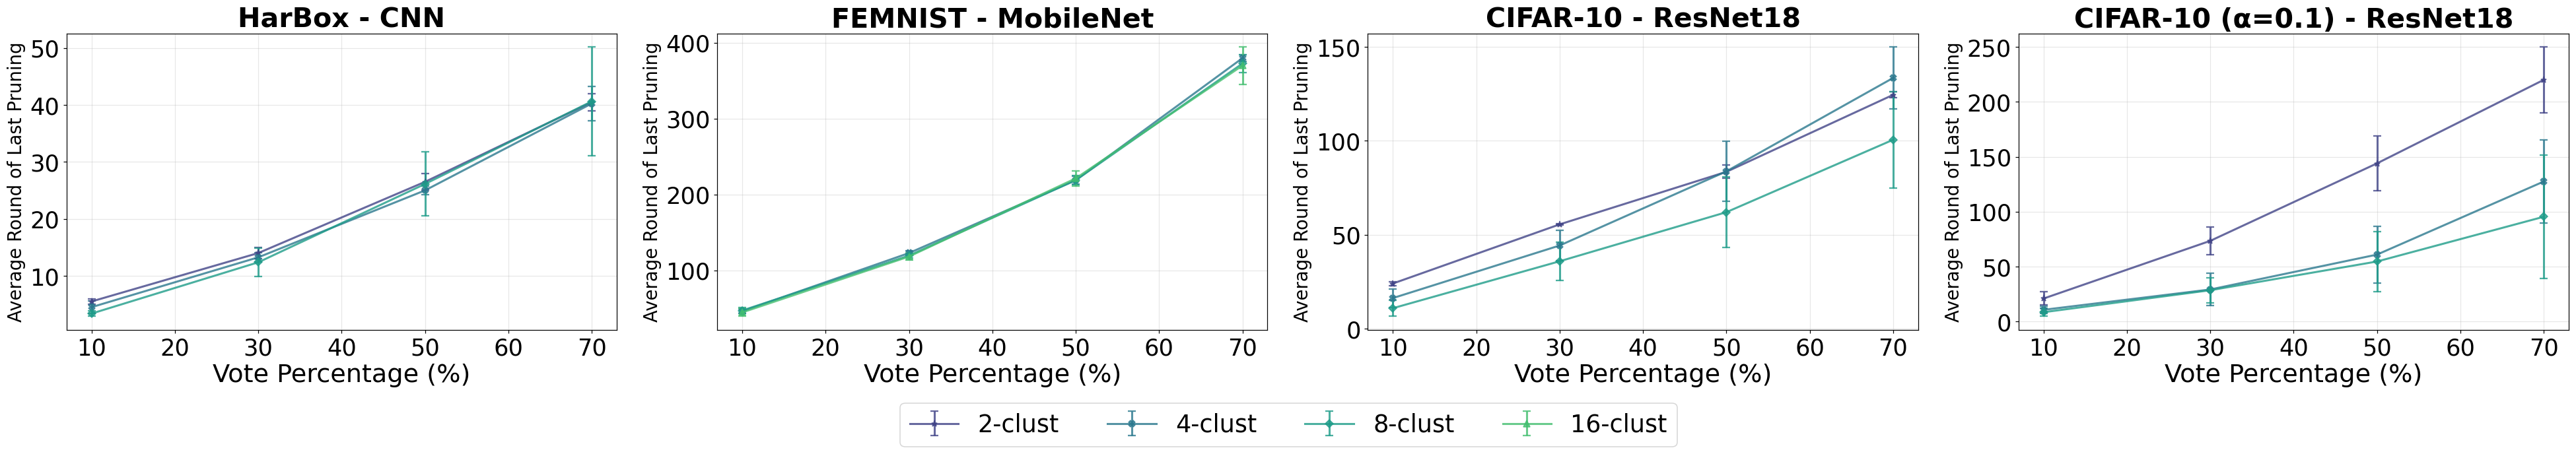

In [ ]:
# Plot average pruning round vs consensus percentage
# Create figure with 3 subplots (one per dataset)
from collections import defaultdict

plt.close()

# Increase font sizes for all plot elements
plt.rcParams.update(
    {
        "font.size": 25,
        "axes.titlesize": 27,
        "axes.labelsize": 25,
        "xtick.labelsize": 23,
        "ytick.labelsize": 23,
        "legend.fontsize": 24,
        "figure.titlesize": 29,
        "legend.title_fontsize": 24,
    }
)

n_ds = len(results_by_dataset_rq2)
fig, axes = plt.subplots(1, n_ds, figsize=(9 * n_ds, 6))
axes = np.atleast_1d(axes)

# Store all line objects and labels for shared legend
legend_items = {}  # {cluster_size: (line, label)}

# Use viridis colormap with fixed positions for all 4 cluster sizes
colors = plt.cm.viridis([CLUSTER_DIRECT_COLOR_MAP[k] for k in sorted(MARKER_POOL.keys(), key=int)])
color_map = {size: colors[i] for i, size in enumerate(sorted(MARKER_POOL.keys(), key=int))}

print(color_map)

for ax_idx, (dataset_name, results_dict) in enumerate(
    sorted(results_by_dataset_rq2.items(), key=lambda x: DATASET_ORDER[x[0]])
):
    ax = axes[ax_idx]

    # Group by (cluster_size, consensus_percentage)
    cluster_size_pruning_data = defaultdict(lambda: defaultdict(list))

    for run_name, data in results_dict.items():
        # Only consider runs with pruning events
        if "pruning_events" in data and data["pruning_events"]:
            consensus_percent = data.get("consensus_percentage", 0.5)

            # Extract cluster size from run name
            # Format: "N-clust-vote-..." or "N-clust-..."
            if "clust" in run_name:
                parts = run_name.replace("_", "-").split("-")
                cluster_size = parts[0]

                if cluster_size in MARKER_POOL:
                    # Find the maximum (last) pruning round for each group in this run
                    group_max_rounds = {}  # {group_id: max_round}
                    for event in data["pruning_events"]:
                        group_id = event["group_id"]
                        round_num = event["round"]

                        if group_id not in group_max_rounds or round_num > group_max_rounds[group_id]:
                            group_max_rounds[group_id] = round_num

                    # Store the last pruning round for each cluster (group)
                    if group_max_rounds:
                        for group_id, last_round in group_max_rounds.items():
                            cluster_size_pruning_data[cluster_size][consensus_percent].append(last_round)

                        print(
                            f"{dataset_name} - {run_name}: cluster_size={cluster_size}, consensus={consensus_percent}, last pruning rounds by group={group_max_rounds}"
                        )

    # Plot each cluster size as a separate line
    for cluster_size in sorted(cluster_size_pruning_data.keys(), key=int):
        consensus_data = cluster_size_pruning_data[cluster_size]

        consensus_percentages = []
        avg_pruning_rounds = []
        std_pruning_rounds = []

        for consensus_percent in sorted(consensus_data.keys()):
            rounds_list = consensus_data[consensus_percent]

            consensus_percentages.append(consensus_percent * 100)  # Convert to percentage
            avg_pruning_rounds.append(np.mean(rounds_list))
            std_pruning_rounds.append(np.std(rounds_list))

            print(
                f"\n{dataset_name} - {cluster_size}-clust @ Consensus {consensus_percent * 100}%: {len(rounds_list)} cluster instances"
            )
            print(f"  Average last pruning round: {np.mean(rounds_list):.2f} ± {np.std(rounds_list):.2f}")
            print(f"  Cluster rounds: {rounds_list}")

        # Get consistent marker and color

        if "FEM" in dataset_name:
            cluster_size = str(int(cluster_size))
        marker = MARKER_POOL[cluster_size]
        color = color_map[cluster_size]

        # Plot this cluster size with error bars
        line = ax.errorbar(
            consensus_percentages,
            avg_pruning_rounds,
            yerr=std_pruning_rounds,
            marker=marker,
            linestyle="-",
            color=color,
            linewidth=2,
            markersize=6,
            capsize=4,
            capthick=1.5,
            label=f"{cluster_size}-clust",
            alpha=0.8,
        )

        # Store legend items for this cluster size (only once across all datasets)
        if cluster_size not in legend_items:
            legend_items[cluster_size] = (line, f"{cluster_size}-clust")

    ax.set_xlabel("Vote Percentage (%)")
    ax.set_ylabel("Average Round of Last Pruning",fontsize=18)
    ax.set_title(f"{DATASET_MODEL_MAP[dataset_name]}", fontweight="bold")
    ax.grid(True, alpha=0.3)

    print(f"\n{dataset_name}: Plotted {len(cluster_size_pruning_data)} cluster configurations")

# Create a shared legend below all subplots with all cluster configurations (sorted by cluster size)
all_lines = []
all_labels = []
for cluster_size in sorted(legend_items.keys(), key=int):
    line, label = legend_items[cluster_size]
    all_lines.append(line)
    all_labels.append(label)

fig.legend(all_lines, all_labels, loc="lower center", ncols=4, bbox_to_anchor=(0.5, -0.1))

# Overall title
# fig.suptitle(
#     "Average Last Pruning Round vs Vote Percentage (Error bars = std across clusters)",
#     fontsize=28,
#     fontweight="bold",
# )

plt.tight_layout()
plt.show()

print("\nCreated 3-subplot figure with shared legend containing all cluster configurations")

HAR

HAR - 2-clust: 4 runs plotted
  2-clust-vote-1: vote%=10.0, ratio=1.4225
  2-clust-vote-2-best: vote%=30.0, ratio=1.4284
  2-clust-vote-3: vote%=50.0, ratio=1.4124
  2-clust-vote-4: vote%=70.0, ratio=1.3956

HAR - 4-clust: 4 runs plotted
  4-clust-vote-1: vote%=10.0, ratio=1.4499
  4-clust-vote-2-best: vote%=30.0, ratio=1.4425
  4-clust-vote-3: vote%=50.0, ratio=1.4033
  4-clust-vote-4: vote%=70.0, ratio=1.3772

HAR - 8-clust: 4 runs plotted
  8-clust-vote-1: vote%=10.0, ratio=1.4923
  8-clust-vote-2-best: vote%=30.0, ratio=1.4753
  8-clust-vote-3: vote%=50.0, ratio=1.4566
  8-clust-vote-4: vote%=70.0, ratio=1.4302
FEMNIST

FEMNIST - 4-clust: 4 runs plotted
  4-clust-vote-1: vote%=10.0, ratio=2.1165
  4-clust-vote-2: vote%=30.0, ratio=1.9161
  4-clust-vote-3-best: vote%=50.0, ratio=1.6911
  4-clust-vote-4: vote%=70.0, ratio=1.4718

FEMNIST - 8-clust: 4 runs plotted
  8-clust-vote-1-best: vote%=10.0, ratio=2.1875
  8-clust-vote-2: vote%=30.0, ratio=1.8898
  8-clust-vote-3: vote%=50

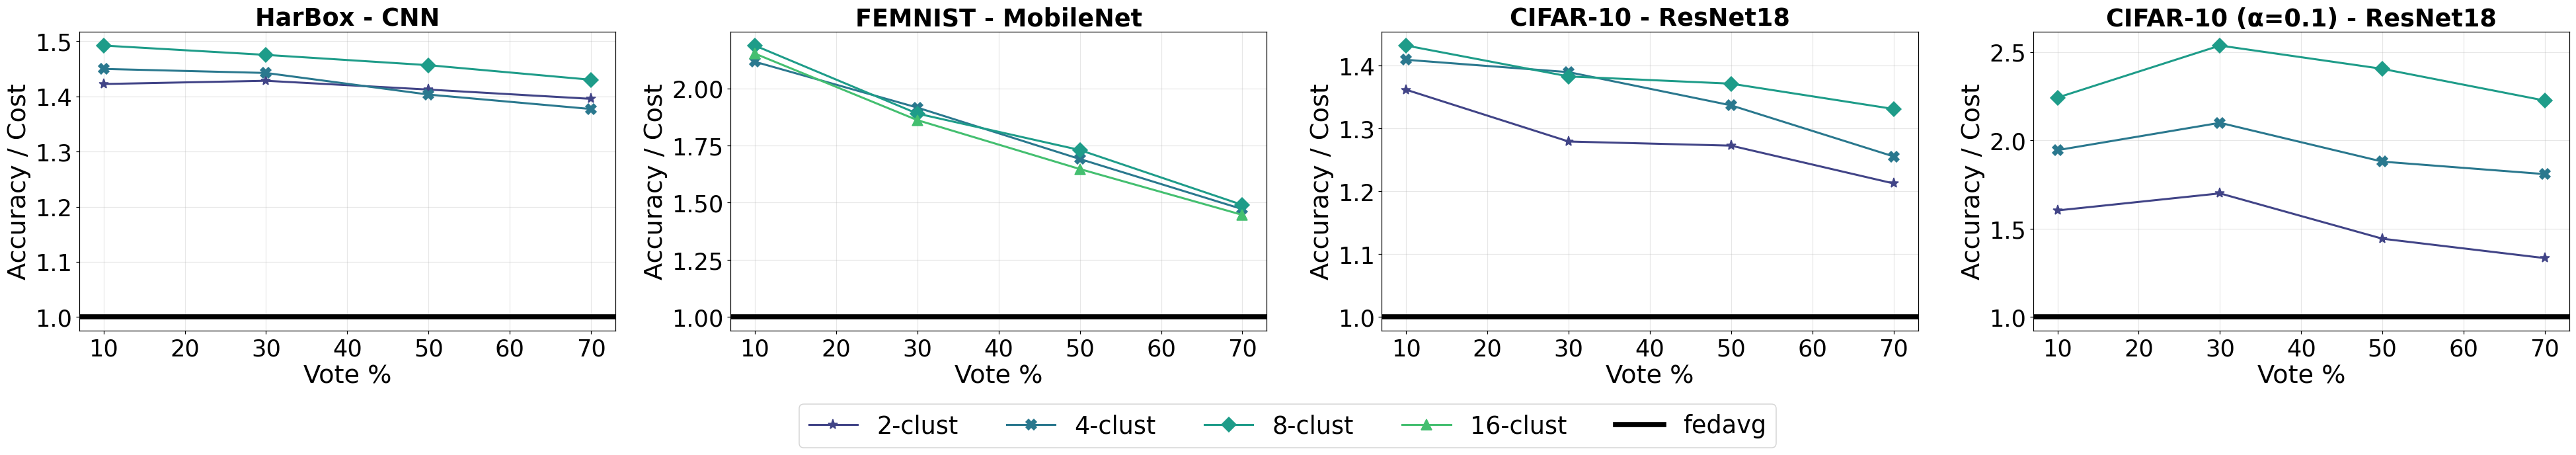

In [ ]:
# Plot Accuracy/Cost Ratio vs Consensus Percentage for each dataset
from collections import defaultdict

plt.close()

plt.rcParams.update(
    {
        "font.size": 25,
        "axes.titlesize": 27,
        "axes.labelsize": 25,
        "xtick.labelsize": 23,
        "ytick.labelsize": 23,
        "legend.fontsize": 24,
        "figure.titlesize": 29,
        "legend.title_fontsize": 24,
    }
)

n_ds = len(results_by_dataset_rq2)
fig, axes = plt.subplots(1, n_ds, figsize=(9 * n_ds, 6))
axes = np.atleast_1d(axes)

# Store all line objects and labels for shared legend
legend_items = {}  # {cluster_size: (line, label)}

fedavg_baseline_costs_rq2 = {
    "FEMNIST": 377405.2047729492 ,
    "HAR": 582.4843597412109 ,
    "CIFAR10": 427473.03634643555 ,
    "CIFAR10_dir0.1": 426619.80 ,
}

fedavg_baseline_acc_rq2 = {
    "CIFAR10": 0.5077,
    "FEMNIST": 0.7344,
    "HAR": 0.8269,
    "CIFAR10_dir0.1": 0.336,
}

# Use viridis colormap with fixed positions for all 4 cluster sizes
colors = plt.cm.viridis([CLUSTER_DIRECT_COLOR_MAP[k] for k in sorted(MARKER_POOL.keys(), key=int)])
color_map = {size: colors[i] for i, size in enumerate(sorted(MARKER_POOL.keys(), key=int))}

# Track global min and max ratios across all datasets
global_min_ratio = float("inf")
global_max_ratio = float("-inf")

for ax_idx, (dataset_name, results_dict) in enumerate(
    sorted(results_by_dataset_rq2.items(), key=lambda x: DATASET_ORDER[x[0]])
):
    ax = axes[ax_idx]
    print(dataset_name)

    consensus_cluster_runs = defaultdict(list)

    fedavg_ratio = fedavg_baseline_acc_rq2[dataset_name] / fedavg_baseline_costs_rq2[dataset_name]

    c = fedavg_baseline_costs_rq2[dataset_name] / fedavg_baseline_acc_rq2[dataset_name]

    line_avg = ax.axhline(
        y=fedavg_ratio * c,
        label="fedavg",
        color="black",
        linewidth=5,
    )

    for run_name, data in results_dict.items():
        # Extract cluster size from run name
        # Format: "N-clust-vote-<identifier>" or "N-clusters-<identifier>"
        if "clust" in run_name:
            # Extract N (cluster size)
            parts = run_name.replace("_", "-").split("-")
            cluster_size = parts[0]

            if cluster_size in MARKER_POOL:
                # Check if this is a vote run
                if "vote" in run_name:
                    # Calculate accuracy/cost ratio
                    accuracy = data["server_accuracy"]
                    cost_mb = data["total_cost_mb"]

                    # Convert to appropriate units
                    if dataset_name != "HAR":
                        cost_gb = cost_mb 
                        ratio = accuracy / cost_gb * c if cost_gb > 0 else 0
                        unit = ""
                    else:
                        ratio = accuracy / cost_mb * c if cost_mb > 0 else 0
                        unit = ""

                    # Track global min/max
                    global_min_ratio = min(global_min_ratio, ratio)
                    global_max_ratio = max(global_max_ratio, ratio)

                    consensus_cluster_runs[cluster_size].append(
                        {
                            "run_name": run_name,
                            "consensus_percentage": data.get("consensus_percentage", 0.5),
                            "accuracy_cost_ratio": ratio,
                            "unit": unit,
                        }
                    )

    # Sort each cluster's runs by consensus_percentage
    for cluster_size in consensus_cluster_runs:
        consensus_cluster_runs[cluster_size].sort(key=lambda x: x["consensus_percentage"])

    # Set up axis labels
    ax.set_xlabel("Vote %")
    ax.set_ylabel("Accuracy / Cost")

    # Plot each cluster size
    for cluster_size in sorted(consensus_cluster_runs.keys(), key=int):
        runs = consensus_cluster_runs[cluster_size]

        if not runs:
            continue

        # Extract data
        consensus_percentages = [r["consensus_percentage"] * 100 for r in runs]
        ratios = [r["accuracy_cost_ratio"] for r in runs]

        if "FEM" in dataset_name:
            cluster_size = str(int(cluster_size))

        # Get consistent marker and color
        marker = MARKER_POOL[cluster_size]
        color = color_map[cluster_size]

        # Plot ratio
        line = ax.plot(
            consensus_percentages,
            ratios,
            marker=marker,
            linestyle="-",
            color=color,
            label=f"{cluster_size}-clust",
            linewidth=2,
            markersize=10,
        )[0]

        # Store legend items for this cluster size (only once across all datasets)
        if cluster_size not in legend_items:
            legend_items[cluster_size] = (line, f"{cluster_size}-clust")

        print(f"\n{dataset_name} - {cluster_size}-clust: {len(runs)} runs plotted")
        for r in runs:
            print(
                f"  {r['run_name']}: vote%={r['consensus_percentage'] * 100:.1f}, ratio={r['accuracy_cost_ratio']:.4f}"
            )

    # Add grid
    ax.grid(True, alpha=0.3)

    # Set subplot title
    ax.set_title(f"{DATASET_MODEL_MAP[dataset_name]}", fontsize=24, fontweight="bold")

# Set consistent y-axis limits across all subplots with ±5% margin
y_margin = 0.05 * (global_max_ratio - global_min_ratio)
y_min = global_min_ratio - y_margin
y_max = global_max_ratio + y_margin

# for ax in axes:
#     ax.set_yscale("log",base=2)
# ax.set_ylim(y_min, y_max)

# Create a shared legend below all subplots with all cluster configurations (sorted by cluster size)
all_lines = []
all_labels = []
for cluster_size in sorted(legend_items.keys(), key=int):
    line, label = legend_items[cluster_size]
    all_lines.append(line)
    all_labels.append(label)

fig.legend(
    all_lines + [line_avg],
    all_labels + ["fedavg"],
    loc="lower center",
    ncols=5,
    bbox_to_anchor=(0.5, -0.1),
)

# Overall title
# fig.suptitle(
#     "Accuracy/Cost Ratio vs Vote Percentage by Cluster Configuration",
#     fontsize=28,
#     fontweight="bold",
# )

plt.tight_layout()
plt.show()

print("\nCreated 3-subplot figure with Accuracy/Cost ratio")
print(f"All cluster configurations in legend: {sorted(legend_items.keys(), key=int)}")

# RQ1 answer

In [ ]:
import pickle

# Filepath to save both variables
_SAVE_PATH = "best_runs_with_cluster_cost-har.pkl"

# Save variables to disk
with open(_SAVE_PATH, "wb") as f:
    pickle.dump(
        {
            "best_runs_with_cluster_cost": best_runs_with_cluster_cost,
        },
        f,
        protocol=pickle.HIGHEST_PROTOCOL,
    )

print(
    f"Saved best_runs_with_cluster_cost ({len(best_runs_with_cluster_cost)} keys)"
    f"({sum(len(v) for v in best_runs_with_cluster_cost.values())} runs) -> {_SAVE_PATH}"
)

Saved best_runs_with_cluster_cost (6 keys)(54 runs) -> best_runs_with_cluster_cost-har.pkl


In [ ]:
import pickle

# Filepath to save both variables
_SAVE_PATH = "best_runs_with_cluster_cost.pkl"

# --- Load back ---
with open(_SAVE_PATH, "rb") as f:
    _loaded = pickle.load(f)

# Reassign to the same variable names (overwrites current in-memory objects)
best_runs_with_cluster_cost = _loaded["best_runs_with_cluster_cost"]


print(
    f"Loaded best_runs_with_cluster_cost ({len(best_runs_with_cluster_cost)} keys)"
    f"({sum(len(v) for v in best_runs_with_cluster_cost.values())} runs) from {_SAVE_PATH}"
)

Loaded best_runs_with_cluster_cost (4 keys)(36 runs) from best_runs_with_cluster_cost.pkl


In [ ]:
old_best_runs_with_cluster_cost = best_runs_with_cluster_cost

In [ ]:
# Collect metrics from "best" runs with cluster communication cost aggregation
# sweep_ids_to_analyze = [
#     "ICDCS/FEMNIST/zhmp23re",
#     "ICDCS/FEMNIST/l0iddhdn",
#     "ICDCS/FEMNIST/m21qv60k",
#     "ICDCS/FEMNIST/prwjcuz7",
#     "ICDCS/FEMNIST/d9tfpbnu",
# ]  # FEMNIST


# sweep_ids_to_analyze = [
#     "ICDCS/FedCIFAR10/5dc8bowz",
#     "ICDCS/FedCIFAR10/5jx8ivoz",
#     "ICDCS/FedCIFAR10/g0bh63nu",
#     "ICDCS/FedCIFAR10/v42ct5rp",
# ]  # CIFAR10

sweep_ids_to_analyze = [
    "ICDCS/FedHAR/3roxjunr",
    "ICDCS/FedHAR/466cobzl",
    "ICDCS/FedHAR/b74scpxu",
    "ICDCS/FedHAR/z1bajio2",
]  # HAR


# Define metrics to collect
metrics_to_collect = ["Server/Test/Acc", "Test/Acc", "Personal/Test/Acc"]

# Dictionary to store best run results with cluster cost aggregation
best_runs_with_cluster_cost = {}

print("=" * 80)
print("Collecting metrics from 'best' runs with cluster cost aggregation")
print(f"Metrics to collect: {metrics_to_collect}")
print("=" * 80)

for sweep_id in sweep_ids_to_analyze:
    print(f"\nSweep: {sweep_id}")
    print("-" * 80)

    # Get the sweep
    sweep = api.sweep(sweep_id)
    sweep_runs = sweep.runs

    for run in sweep_runs:
        # Check if "best" is in the run name (case-insensitive)
        if "best" not in run.name.lower() or run.name in best_runs_with_cluster_cost:
            continue

        print(f"\nProcessing run: {run.name}")

        # Initialize result dict for this run
        run_metrics = {"sweep_id": sweep_id, "run_name": run.name, "run_id": run.id, "config": run.config}

        # Collect each metric by round
        rounds_data = {}  # {round_num: {metric: value}}

        # For communication cost, we need to sum across all groups
        round_costs = {}  # {round_num: total_cost}

        # Build list of keys to fetch
        group_upload_keys = [f"CommCost/Group_{i}/Total/Combined" for i in range(16)]
        all_keys = metrics_to_collect + ["round", "CommCost/Total/Combined"] + group_upload_keys

        for key in all_keys:
            for row in run.scan_history(keys=[key, "round"]):
                round_num = row["round"]
                if round_num is None:
                    continue

                if round_num not in rounds_data:
                    rounds_data[round_num] = {}

                val = row[key]

                if key == "CommCost/Total/Combined" or "CommCost/Group" in key:
                    if round_num not in round_costs:
                        round_costs[round_num] = 0
                    round_costs[round_num] += val
                else:
                    rounds_data[round_num][key] = val

        # Convert to lists indexed by round
        if rounds_data:
            sorted_rounds = sorted(rounds_data.keys())
            run_metrics["rounds"] = sorted_rounds

            # Store regular metrics
            for metric_name in metrics_to_collect:
                metric_values = [rounds_data[r].get(metric_name) for r in sorted_rounds]
                run_metrics[metric_name] = metric_values

                # Print summary
                valid_values = [v for v in metric_values if v is not None]
                if valid_values:
                    print(f"  {metric_name}: {len(valid_values)} values across {len(sorted_rounds)} rounds")
                    print(f"    First: {valid_values[0]:.4f}, Last: {valid_values[-1]:.4f}")
                else:
                    print(f"  {metric_name}: No data found")

            # Store communication cost (sum across all clusters/groups)
            comm_cost_values = [round_costs.get(r, 0) for r in sorted_rounds]

            # Calculate cumulative sum
            cumulative_cost = np.cumsum(comm_cost_values)
            run_metrics["CommCost/Total"] = cumulative_cost.tolist()

            # Convert to MB for display
            comm_cost_mb = [c / (1024 * 1024) for c in cumulative_cost]
            total_cost_mb = comm_cost_mb[-1] if len(comm_cost_mb) > 0 else 0

            print(f"  CommCost/Total: {len(comm_cost_values)} values across {len(sorted_rounds)} rounds")
            print(f"    Total: {total_cost_mb:.2f} MB, Per round avg: {total_cost_mb / len(sorted_rounds):.2f} MB")
        else:
            run_metrics["rounds"] = []
            for metric_name in metrics_to_collect:
                run_metrics[metric_name] = []
            run_metrics["CommCost/Total"] = []
            print("  No round data found")

        # Store in results dictionary
        best_runs_with_cluster_cost[run.name] = run_metrics

print("\n" + "=" * 80)
print(f"Collected metrics from {len(best_runs_with_cluster_cost)} 'best' runs")
print("Results stored in 'best_runs_with_cluster_cost'")
print("Communication cost aggregated across all clusters/groups per round")
print("=" * 80)

Metrics to collect: ['Server/Test/Acc', 'Test/Acc', 'Personal/Test/Acc']

Sweep: ICDCS/FedHAR/3roxjunr
--------------------------------------------------------------------------------

Processing run: fedavg-best
  Server/Test/Acc: 51 values across 500 rounds
    First: 0.2635, Last: 0.7343
  Test/Acc: 51 values across 500 rounds
    First: 0.1667, Last: 0.9223
  Personal/Test/Acc: No data found
  CommCost/Total: 500 values across 500 rounds
    Total: 4659.87 MB, Per round avg: 9.32 MB

Sweep: ICDCS/FedHAR/466cobzl
--------------------------------------------------------------------------------

Processing run: scaffold-best
  Server/Test/Acc: 51 values across 500 rounds
    First: 0.1473, Last: 0.7257
  Test/Acc: 51 values across 500 rounds
    First: 0.1353, Last: 0.7118
  Personal/Test/Acc: No data found
  CommCost/Total: 500 values across 500 rounds
    Total: 4659.87 MB, Per round avg: 9.32 MB

Sweep: ICDCS/FedHAR/b74scpxu
---------------------------------------------------------

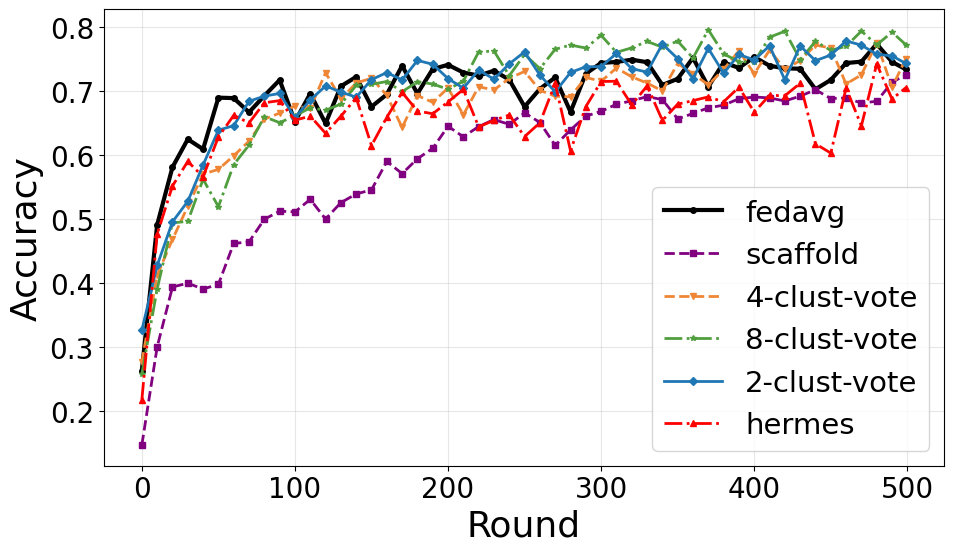

Plotted 6 runs for ['Server/Test/Acc']


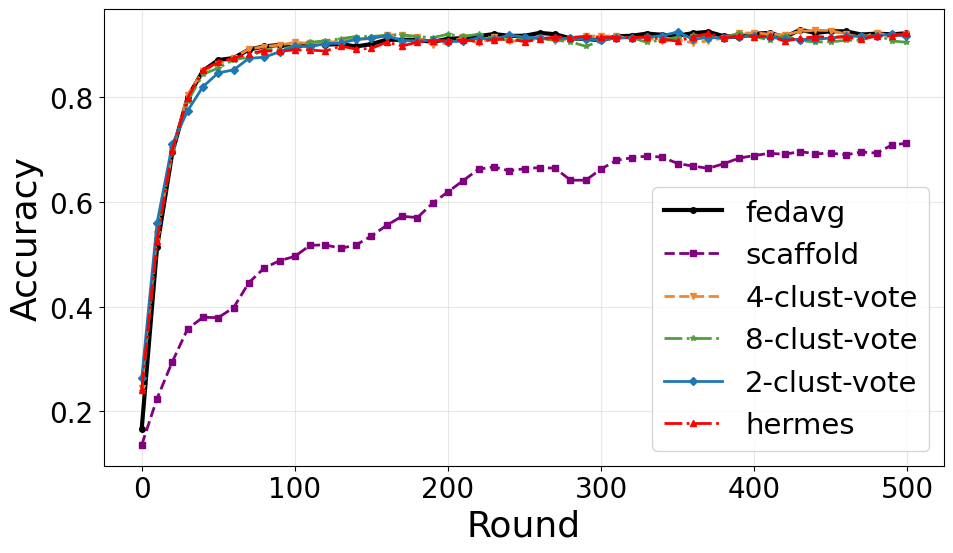

Plotted 6 runs for ['Test/Acc', 'Personal/Test/Acc']


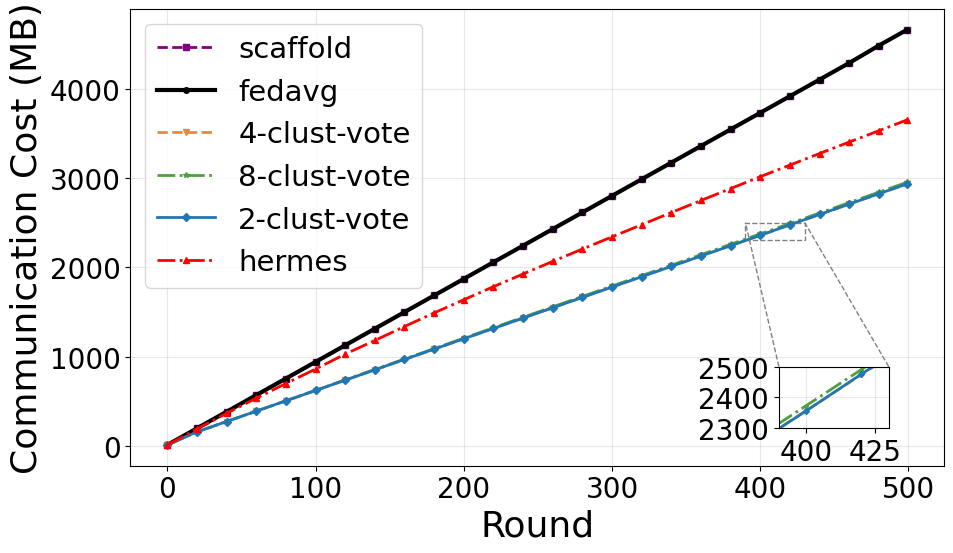

Plotted 5 runs for ['CommCost/Total']


In [ ]:
# Plot metrics from best_runs_with_cluster_cost
# Create separate plots for each metric (Test/Acc and Personal/Test/Acc share the same plot)
# Increase font sizes for all plot elements
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
plt.rcParams.update(
    {
        "font.size": 22,
        "axes.titlesize": 24,
        "axes.labelsize": 26,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
        "legend.fontsize": 21,
        "figure.titlesize": 26,
        "legend.title_fontsize": 21,
    }
)

plot_titles = {
    "Personal" : "Local Test Acc. for each Round",
    "Server" : "Global Test Acc. for each Round",
    "CommCost" : "Total Communication Cost for each Round"
}


def clean_run_name(name):
    """Remove '-<Number>-best' or '-best' suffix from run names"""
    import re

    # Remove pattern like '-0-best', '-1-best', etc. or just '-best'
    cleaned = re.sub(r"-\d+-best$", "", name)
    cleaned = re.sub(r"-best$", "", cleaned)
    return cleaned


metrics_to_plot = ["Server/Test/Acc", ["Test/Acc", "Personal/Test/Acc"], "CommCost/Total"]

# Define color scheme, markers, and linestyles for different configurations
config_styles = {
    "fedavg": {"color": "black", "marker": "o", "linestyle": "-", "linewidth": 3, "markersize": 15},
    "scaffold": {"color": "purple", "marker": "s", "linestyle": "--", "linewidth": 2},
    "hermes": {"color": "red", "marker": "^", "linestyle": "-.", "linewidth": 2},
    "2-clust": {"color": "#1f77b4", "marker": "D", "linestyle": "-", "linewidth": 2},
    "4-clust": {"color": "#EF8636", "marker": "v", "linestyle": "--", "linewidth": 2},
    "8-clust": {"color": "#519E3E", "marker": "*", "linestyle": "-.", "linewidth": 2},
}

# Detect dataset from sweep_ids_to_analyze
dataset_name = "HAR"  # Default

for metric_entry in metrics_to_plot:
    plt.figure(figsize=(10, 6))

    # Handle both single metric and list of metrics
    if isinstance(metric_entry, list):
        metrics_for_plot = metric_entry
    else:
        metrics_for_plot = [metric_entry]
        
    for key, title in plot_titles.items() :
        if isinstance(metric_entry,list):
            for el in metric_entry :
                if key in el:
                    plot_title = title
        elif key in metric_entry :
            plot_title = title

    plotted_runs = 0
    is_comm_cost_plot = "CommCost/Total" in metrics_for_plot
    
    for run_name, run_data in best_runs_with_cluster_cost.items():
        rounds = run_data["rounds"]

        # Skip fedavg when plotting communication cost
        if is_comm_cost_plot and "fedavg" in run_name.lower():
            continue

        # Determine style based on run name
        style = None
        for key, style_config in config_styles.items():
            if key in run_name.lower():
                style = style_config
                break

        # Default style if no match found
        if style is None:
            style = {"color": "gray", "marker": "o", "linestyle": "-", "linewidth": 2}

        # Check if this run has any of the metrics we're plotting
        for metric_name in metrics_for_plot:
            metric_values = run_data[metric_name]

            # Filter out None values
            valid_data = [(r, v) for r, v in zip(rounds, metric_values) if v is not None]

            if valid_data:
                valid_rounds, valid_values = zip(*valid_data)

                # Convert communication cost to MB or GB based on dataset
                if metric_name == "CommCost/Total":
                    # Sample every 20 rounds
                    sampled_data = [
                        (r, v)
                        for i, (r, v) in enumerate(zip(valid_rounds, valid_values))
                        if i % 20 == 0 or i == len(valid_rounds) - 1
                    ]
                    if sampled_data:
                        valid_rounds, valid_values = zip(*sampled_data)
                    # For CIFAR10 and FEMNIST, convert to GB; for HAR, keep MB
                    if dataset_name in ["CIFAR10", "FEMNIST"]:
                        valid_values = [v / (1024 * 1024 * 1024) for v in valid_values if v != 0]
                    else:
                        valid_values = [v / (1024 * 1024) for v in valid_values if v != 0]

                # Create label with metric name if plotting multiple metrics
                label = run_name

                if len(valid_values) > 0:
                    plt.plot(
                        valid_rounds,
                        valid_values,
                        marker=style["marker"],
                        color=style["color"],
                        linestyle=style["linestyle"],
                        linewidth=style["linewidth"],
                        label=clean_run_name(label),
                        markersize=4,
                    )
                    plotted_runs += 1
                    
                    # For scaffold on communication cost plots, plot again with fedavg label
                    if is_comm_cost_plot and "scaffold" in run_name.lower():
                        fedavg_style = config_styles["fedavg"]
                        plt.plot(
                            valid_rounds,
                            valid_values,
                            marker=fedavg_style["marker"],
                            color=fedavg_style["color"],
                            linestyle=fedavg_style["linestyle"],
                            linewidth=fedavg_style["linewidth"],
                            label="fedavg",
                            markersize=4,
                        )

    if plotted_runs > 0:
        plt.xlabel("Round")

        if "CommCost/Total" in metrics_for_plot:
            if dataset_name in ["CIFAR10", "FEMNIST"]:
                plt.ylabel("Communication Cost (GB)")
            else:
                plt.ylabel("Communication Cost (MB)")
        else:
            plt.ylabel("Accuracy")

        # plt.title(plot_title)
        plt.legend(loc="best")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        # Add zoomed inset only for communication cost plots
        if is_comm_cost_plot:
            # Create inset axes for zoomed view
            parent = plt.gca()
            axins = inset_axes(parent, width="15%", height="15%", loc="lower right", 
                              bbox_to_anchor=(0.05, 0.05, 0.9, 0.9), bbox_transform=parent.transAxes)
            
            # Plot the same data in the inset
            for run_name, run_data in best_runs_with_cluster_cost.items():
                rounds = run_data["rounds"]
                
                if "fedavg" in run_name.lower():
                    continue
                    
                style = None
                for key, style_config in config_styles.items():
                    if key in run_name.lower():
                        style = style_config
                        break
                        
                if style is None:
                    style = {"color": "gray", "marker": "o", "linestyle": "-", "linewidth": 2}
                    
                for metric_name in metrics_for_plot:
                    metric_values = run_data[metric_name]
                    valid_data = [(r, v) for r, v in zip(rounds, metric_values) if v is not None]
                    
                    if valid_data:
                        valid_rounds, valid_values = zip(*valid_data)
                        
                        if metric_name == "CommCost/Total":
                            sampled_data = [
                                (r, v)
                                for i, (r, v) in enumerate(zip(valid_rounds, valid_values))
                                if i % 20 == 0 or i == len(valid_rounds) - 1
                            ]
                            if sampled_data:
                                valid_rounds, valid_values = zip(*sampled_data)
                            
                            if dataset_name in ["CIFAR10", "FEMNIST"]:
                                valid_values = [v / (1024 * 1024 * 1024) for v in valid_values if v != 0]
                            else:
                                valid_values = [v / (1024 * 1024) for v in valid_values if v != 0]
                            
                            if len(valid_values) > 0:
                                axins.plot(
                                    valid_rounds,
                                    valid_values,
                                    marker=style["marker"],
                                    color=style["color"],
                                    linestyle=style["linestyle"],
                                    linewidth=style["linewidth"],
                                    markersize=3,
                                )
                                
                                if "scaffold" in run_name.lower():
                                    fedavg_style = config_styles["fedavg"]
                                    axins.plot(
                                        valid_rounds,
                                        valid_values,
                                        marker=fedavg_style["marker"],
                                        color=fedavg_style["color"],
                                        linestyle=fedavg_style["linestyle"],
                                        linewidth=fedavg_style["linewidth"],
                                        markersize=3,
                                    )
            
            # Set zoom region (adjust these values based on your data)
            x1, x2, y1, y2 = 390, 430, 2300, 2500
            axins.set_xlim(x1, x2)
            axins.set_ylim(y1, y2)
            axins.grid(True, alpha=0.3)
            
            
            # Mark the inset region
            mark_inset(parent, axins, loc1=1, loc2=2,fc="none", ec="0.5", linestyle="--") #  
        plt.show()

        print(f"Plotted {plotted_runs} runs for {metrics_for_plot}")
    else:
        print(f"No data to plot for {metrics_for_plot}")
        plt.close()

# Plots commcost x cluster

In [ ]:
# Collect metrics from "best" runs with cluster communication cost aggregation for all three datasets

# Define all three datasets with their sweep IDs
datasets_config = {
    "FEMNIST": [
        "ICDCS/FEMNIST/6wug73uc",
        "ICDCS/FEMNIST/m21qv60k",
        "ICDCS/FEMNIST/prwjcuz7",
        "ICDCS/FEMNIST/d9tfpbnu",
    ],
    "CIFAR10": [
        "ICDCS/FedCIFAR10/5dc8bowz",
        "ICDCS/FedCIFAR10/5jx8ivoz",
        "ICDCS/FedCIFAR10/g0bh63nu",
    ],
    "HAR": [
        "ICDCS/FedHAR/3roxjunr",
        "ICDCS/FedHAR/466cobzl",
        "ICDCS/FedHAR/b74scpxu",
        "ICDCS/FedHAR/z1bajio2",
    ],
}

# Dictionary to store best run results with cluster cost aggregation for each dataset
all_datasets_results = {}

print("=" * 80)
print("Collecting communication cost from 'best' runs for all three datasets")
print("=" * 80)

for dataset_name, sweep_ids_to_analyze in datasets_config.items():
    print(f"\n{'=' * 80}")
    print(f"Processing dataset: {dataset_name}")
    print(f"{'=' * 80}")

    best_runs_with_cluster_cost = {}

    for sweep_id in sweep_ids_to_analyze:
        print(f"\nSweep: {sweep_id}")
        print("-" * 80)

        # Get the sweep
        sweep = api.sweep(sweep_id)
        sweep_runs = sweep.runs

        for run in sweep_runs:
            # Check if "best" is in the run name (case-insensitive)
            if "best" not in run.name.lower():
                continue

            print(f"\nProcessing run: {run.name}")

            # Initialize result dict for this run
            run_metrics = {"sweep_id": sweep_id, "run_name": run.name, "run_id": run.id, "config": run.config}

            # Collect each metric by round
            rounds_data = {}  # {round_num: {metric: value}}

            # For communication cost, we need to sum across all groups and count groups
            round_costs = {}  # {round_num: total_cost}
            round_group_counts = {}  # {round_num: number of groups with data}

            # Build list of keys to fetch
            group_upload_keys = [f"CommCost/Group_{i}/Total/Combined" for i in range(16)]
            all_keys = ["round", "CommCost/Total/Combined"] + group_upload_keys

            for key in all_keys:
                for row in run.scan_history(keys=[key, "round"]):
                    round_num = row["round"]
                    if round_num is None:
                        continue

                    if round_num not in rounds_data:
                        rounds_data[round_num] = {}

                    val = row[key]

                    if key == "CommCost/Total/Combined" or "CommCost/Group" in key:
                        if round_num not in round_costs:
                            round_costs[round_num] = 0
                            round_group_counts[round_num] = 0
                        if val is not None and val > 0:
                            round_costs[round_num] += val
                            round_group_counts[round_num] += 1

            # Convert to lists indexed by round
            if rounds_data:
                sorted_rounds = sorted(rounds_data.keys())
                run_metrics["rounds"] = sorted_rounds

                # Calculate average communication cost per round (total / number of groups)
                avg_cost_values = []
                for r in sorted_rounds:
                    total_cost = round_costs.get(r, 0)
                    num_groups = round_group_counts.get(r, 1)  # Avoid division by zero
                    if num_groups > 0:
                        avg_cost = total_cost / num_groups
                    else:
                        avg_cost = 0
                    avg_cost_values.append(avg_cost)

                # Calculate cumulative sum of average cost
                cumulative_avg_cost = np.cumsum(avg_cost_values)
                run_metrics["CommCost/Avg"] = cumulative_avg_cost.tolist()

                # Convert to MB for display
                comm_cost_mb = [c / (1024 * 1024) for c in cumulative_avg_cost]
                total_cost_mb = comm_cost_mb[-1] if len(comm_cost_mb) > 0 else 0
                avg_groups = np.mean([round_group_counts.get(r, 0) for r in sorted_rounds])

                print(f"  CommCost/Avg: {len(avg_cost_values)} values across {len(sorted_rounds)} rounds")
                print(f"    Cumulative Avg Total: {total_cost_mb:.2f} MB, Avg groups per round: {avg_groups:.1f}")
            else:
                run_metrics["rounds"] = []
                run_metrics["CommCost/Avg"] = []
                print("  No round data found")

            # Store in results dictionary
            best_runs_with_cluster_cost[run.name] = run_metrics

    all_datasets_results[dataset_name] = best_runs_with_cluster_cost

    print(f"\n{'=' * 80}")
    print(f"Collected metrics from {len(best_runs_with_cluster_cost)} 'best' runs for {dataset_name}")
    print(f"{'=' * 80}")

print("\n" + "=" * 80)
print("Collected metrics for all three datasets")
print("Results stored in 'all_datasets_results'")
print("Average communication cost = total cost / number of groups per round")
print("=" * 80)


Processing dataset: FEMNIST

Sweep: ICDCS/FEMNIST/6wug73uc
--------------------------------------------------------------------------------

Processing run: 4-clust-vote-2-best
  CommCost/Avg: 500 values across 500 rounds
    Cumulative Avg Total: 233343.74 MB, Avg groups per round: 8.0

Processing run: 8-clust-vote-1-best
  CommCost/Avg: 500 values across 500 rounds
    Cumulative Avg Total: 104650.19 MB, Avg groups per round: 16.0

Processing run: 2-clust-vote-1-best
  CommCost/Avg: 500 values across 500 rounds
    Cumulative Avg Total: 488493.20 MB, Avg groups per round: 4.0

Sweep: ICDCS/FEMNIST/m21qv60k
--------------------------------------------------------------------------------

Processing run: fedavg.-best
  CommCost/Avg: 51 values across 51 rounds
    Cumulative Avg Total: 0.00 MB, Avg groups per round: 0.0

Sweep: ICDCS/FEMNIST/prwjcuz7
--------------------------------------------------------------------------------

Processing run: scaffold-best
  CommCost/Avg: 500 value

NameError: name 'all_datasets_results' is not defined

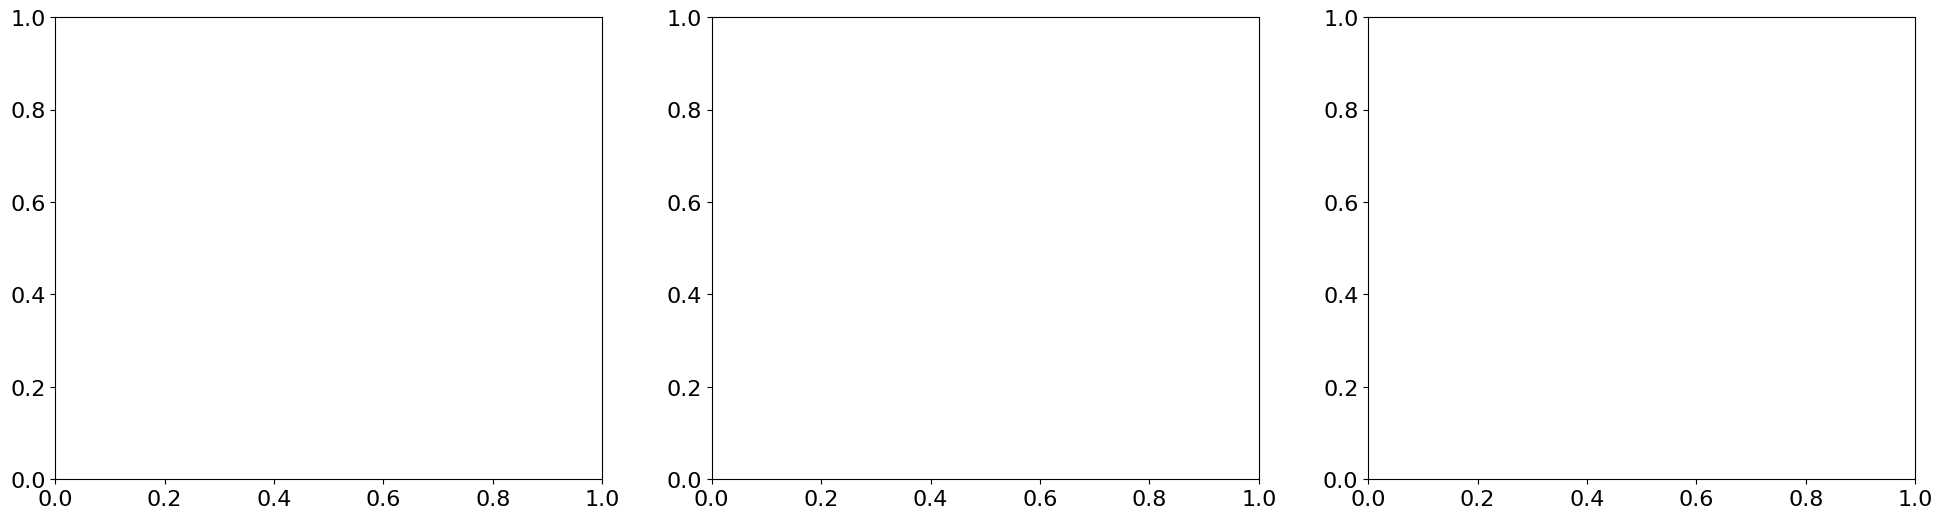

In [ ]:
# Plot average communication cost from all three datasets in a single figure with 3 subplots
# Increase font sizes for all plot elements
plt.rcParams.update(
    {
        "font.size": 18,
        "axes.titlesize": 32,
        "axes.labelsize": 24,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 18,
        "figure.titlesize": 22,
        "legend.title_fontsize": 14,
    }
)


def clean_run_name(name, dataset_name=None):
    """Remove '-<Number>-best' or '-best' suffix from run names and adjust cluster numbers for FEMNIST"""
    import re

    # Remove pattern like '-0-best', '-1-best', etc. or just '-best'
    cleaned = re.sub(r"-\d+-best$", "", name)
    cleaned = re.sub(r"-best$", "", cleaned)

    # For FEMNIST, multiply cluster numbers by 2
    if dataset_name == "FEMNIST":
        cleaned = re.sub(r"8-clust", "16-clust", cleaned)
        cleaned = re.sub(r"4-clust", "8-clust", cleaned)
        cleaned = re.sub(r"2-clust", "4-clust", cleaned)

    return cleaned


# Define color scheme, markers, and linestyles for different configurations
config_styles = {
    "fedavg": {"color": "black", "marker": "o", "linestyle": "-", "linewidth": 3, "markersize": 15},
    "scaffold": {"color": "purple", "marker": "s", "linestyle": "--", "linewidth": 2},
    "hermes": {"color": "red", "marker": "^", "linestyle": "-.", "linewidth": 2},
    "2-clust": {"color": "#1f77b4", "marker": "D", "linestyle": "-", "linewidth": 2},
    "4-clust": {"color": "#EF8636", "marker": "v", "linestyle": "--", "linewidth": 2},
    "8-clust": {"color": "#519E3E", "marker": "*", "linestyle": "-.", "linewidth": 2},
    "16-clust": {"color": "#E377C2", "marker": "P", "linestyle": ":", "linewidth": 2},
}

# Create a figure with 3 subplots in a row
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

datasets_order = ["HAR", "CIFAR10", "FEMNIST"]

for idx, dataset_name in enumerate(datasets_order):
    ax = axes[idx]

    best_runs_with_cluster_cost = all_datasets_results.get(dataset_name, {})

    plotted_runs = 0
    for run_name, run_data in best_runs_with_cluster_cost.items():
        rounds = run_data["rounds"]

        # Determine style based on run name
        style = None
        for key, style_config in config_styles.items():
            if key in run_name.lower():
                style = style_config
                break

        # Default style if no match found
        if style is None:
            style = {"color": "gray", "marker": "o", "linestyle": "-", "linewidth": 2}

        metric_values = run_data["CommCost/Avg"]

        # Filter out None values
        valid_data = [(r, v) for r, v in zip(rounds, metric_values) if v is not None]

        if valid_data:
            valid_rounds, valid_values = zip(*valid_data)

            # Sample every 20 rounds
            sampled_data = [
                (r, v)
                for i, (r, v) in enumerate(zip(valid_rounds, valid_values))
                if i % 20 == 0 or i == len(valid_rounds) - 1
            ]
            if sampled_data:
                valid_rounds, valid_values = zip(*sampled_data)

            # For CIFAR10 and FEMNIST, convert to GB; for HAR, keep MB
            if dataset_name in ["CIFAR10", "FEMNIST"]:
                valid_values = [v / (1024 * 1024 * 1024) for v in valid_values if v != 0]
            else:
                valid_values = [v / (1024 * 1024) for v in valid_values if v != 0]

            label = run_name

            if len(valid_values) > 0:
                ax.plot(
                    valid_rounds,
                    valid_values,
                    marker=style["marker"],
                    color=style["color"],
                    linestyle=style["linestyle"],
                    linewidth=style["linewidth"],
                    label=clean_run_name(label, dataset_name),
                    markersize=4,
                )
                plotted_runs += 1

    if plotted_runs > 0:
        ax.set_xlabel("Round")

        if dataset_name in ["CIFAR10", "FEMNIST"]:
            ax.set_ylabel("Avg Communication Cost (GB)")
        else:
            ax.set_ylabel("Avg Communication Cost (MB)")

        ax.set_title(f"{DATASET_MODEL_MAP[dataset_name]} ")
        ax.legend(loc="best")
        ax.grid(True, alpha=0.3)

        print(f"Plotted {plotted_runs} runs for {dataset_name}")
    else:
        print(f"No data to plot for {dataset_name}")

plt.tight_layout()
plt.show()

print("\nPlotted all three datasets in a single figure")

# Comparison table (methods × datasets)

Personalized / Global test accuracy (%) at 500 rounds. CoMask reported for its 3 cluster configurations (2/4/8; FEMNIST uses 4/8/16). PACFL is a placeholder until run IDs are supplied.

In [ ]:
# === Comparison table: methods x datasets (Personalized / Global test acc %, @500 rounds) ===
# Personalized = Personal/Test/Acc (CoMask/PACFL) else Test/Acc; Global = Server/Test/Acc.
# Existing datasets: best "*best*"-named run by personalized in ICDCS/*. CIFAR-dir0.1: best
# over the whole s-urso2/comask_clust_grid (CoMask) and s-urso2/FedCIFAR10 (FedAvg/SCAFFOLD).
import re as _re

# --- PACFL placeholder: set run paths "entity/project/run_id" when ready ---
PACFL_RUN_IDS = {"FEMNIST": None, "HAR": None, "CIFAR10": None, "CIFAR10_dir0.1": None}

_ICDCS = {
    "FEMNIST": ("ICDCS/FEMNIST", [4, 8, 16]),
    "HAR": ("ICDCS/FedHAR", [2, 4, 8]),
    "CIFAR10": ("ICDCS/FedCIFAR10", [2, 4, 8]),
}

def _classify_best(name):
    n = name.lower()
    if "fedavg" in n: return ("fedavg", None)
    if "scaffol" in n: return ("scaffold", None)
    if "hermes" in n: return ("hermes", None)
    m = _re.match(r"(\d+)-clust", n)
    if m: return ("comask", int(m.group(1)))
    return (None, None)

def _best_runs(path):
    chosen = {}
    for r in api.runs(path):
        if r.state != "finished" or "best" not in r.name.lower():
            continue
        method, clust = _classify_best(r.name)
        if method is None:
            continue
        key = method if clust is None else ("comask", clust)
        fm = final_acc_metrics(r)
        if fm["personalized"] is None:
            continue
        if key not in chosen or fm["personalized"] > chosen[key][1]["personalized"]:
            chosen[key] = (r, fm)
    return chosen

def _best_baseline(substr):
    best = None
    for r in api.runs("s-urso2/FedCIFAR10"):
        if r.state != "finished" or substr not in r.name:
            continue
        fm = final_acc_metrics(r)
        sc = fm["personalized"] if fm["personalized"] is not None else fm["global"]
        if sc is None:
            continue
        if best is None or sc > best[1]:
            best = (r, sc, fm)
    return best

_table, _prov = {}, []
for _ds, (_path, _clusters) in _ICDCS.items():
    _ch = _best_runs(_path)
    _table[_ds] = {}
    for _mk in ["fedavg", "scaffold", "hermes"]:
        if _mk in _ch:
            _r, _fm = _ch[_mk]; _table[_ds][_mk] = _fm
            _prov.append(f"{_ds:14s} {_mk:9s} <- {_r.name} ({_r.id})")
        else:
            _table[_ds][_mk] = None
    for _i, _c in enumerate(_clusters):
        _label = f"comask_{_i}"
        if ("comask", _c) in _ch:
            _r, _fm = _ch[("comask", _c)]; _table[_ds][_label] = _fm
            _prov.append(f"{_ds:14s} comask_k={_c:<2d} <- {_r.name} ({_r.id})")
        else:
            _table[_ds][_label] = None

_ds = "CIFAR10_dir0.1"; _table[_ds] = {}
_fed, _sca = _best_baseline("fedavg_dir0.1"), _best_baseline("scaffold_dir0.1")
_table[_ds]["fedavg"] = _fed[2] if _fed else None
_table[_ds]["scaffold"] = _sca[2] if _sca else None
_table[_ds]["hermes"] = None  # not available for CIFAR-dir0.1
if _fed: _prov.append(f"{_ds:14s} fedavg    <- {_fed[0].name} ({_fed[0].id})")
if _sca: _prov.append(f"{_ds:14s} scaffold  <- {_sca[0].name} ({_sca[0].id})")
_cm = {}
for r in api.runs("s-urso2/comask_clust_grid"):
    if r.state != "finished":
        continue
    info = parse_comask_grid_name(r.name)
    if not info:
        continue
    fm = final_acc_metrics(r)
    if fm["personalized"] is None:
        continue
    c = info["cluster_size"]
    if c not in _cm or fm["personalized"] > _cm[c][1]["personalized"]:
        _cm[c] = (r, fm)
for _i, _c in enumerate([2, 4, 8]):
    _label = f"comask_{_i}"
    if _c in _cm:
        _r, _fm = _cm[_c]; _table[_ds][_label] = _fm
        _prov.append(f"{_ds:14s} comask_k={_c:<2d} <- {_r.name} ({_r.id})")
    else:
        _table[_ds][_label] = None

for _ds_k, _rid in PACFL_RUN_IDS.items():
    _table.setdefault(_ds_k, {})
    if _rid:
        _table[_ds_k]["pacfl"] = final_acc_metrics(api.run(_rid))
        _prov.append(f"{_ds_k:14s} pacfl     <- {_rid}")
    else:
        _table[_ds_k]["pacfl"] = None

print("--- chosen runs (provenance) ---")
for _l in _prov:
    print(" ", _l)

_DS_ORDER = ["FEMNIST", "HAR", "CIFAR10", "CIFAR10_dir0.1"]
_DS_DISP = {"FEMNIST": "FEMNIST", "HAR": "HarBox", "CIFAR10": "CIFAR10-dir0.5",
            "CIFAR10_dir0.1": "CIFAR10-dir0.1"}
_ROW_ORDER = ["fedavg", "scaffold", "hermes", "pacfl", "comask_0", "comask_1", "comask_2"]
_ROW_DISP = {"fedavg": "FedAvg", "scaffold": "SCAFFOLD", "hermes": "Hermes", "pacfl": "PACFL",
             "comask_0": "CoMask (k=2 | FEMNIST 4)",
             "comask_1": "CoMask (k=4 | FEMNIST 8)",
             "comask_2": "CoMask (k=8 | FEMNIST 16)"}

def _fmt(cell):
    if cell is None:
        return "—"
    p, g = cell.get("personalized"), cell.get("global")
    ps = f"{p*100:.1f}" if p is not None else "—"
    gs = f"{g*100:.1f}" if g is not None else "—"
    return f"{ps} / {gs}"

_cols = pd.MultiIndex.from_tuples([(_DS_DISP[d], "Pers./Glob.") for d in _DS_ORDER])
_rows = [[_fmt(_table[d].get(rk)) for d in _DS_ORDER] for rk in _ROW_ORDER]
comparison_df = pd.DataFrame(_rows, index=[_ROW_DISP[r] for r in _ROW_ORDER], columns=_cols)
print("\n=== Comparison table (Personalized / Global test acc %, 500 rounds) ===")
try:
    display(comparison_df)
except NameError:
    print(comparison_df.to_string())

os.makedirs("out", exist_ok=True)
with open("out/comparison_table.tex", "w") as _f:
    _f.write(comparison_df.to_latex(
        caption="Personalized / Global test accuracy (\\%) at 500 communication rounds.",
        label="tab:comparison"))
print("LaTeX written to out/comparison_table.tex")
comparison_df


,FEMNIST,HarBox,CIFAR10-dir0.5,CIFAR10-dir0.1
,Pers./Glob.,Pers./Glob.,Pers./Glob.,Pers./Glob.
FedAvg,82.8 / 82.7,92.4 / 73.4,69.8 / 50.8,11.8 / 33.6
SCAFFOLD,73.1 / 75.7,71.2 / 72.6,51.6 / 50.3,32.7 / 32.2
Hermes,78.7 / 81.8,92.2 / 70.5,32.9 / 22.6,—
PACFL,—,—,—,—
CoMask (k=2 | FEMNIST 4),79.6 / 81.8,91.6 / 74.3,60.5 / 37.4,85.9 / 31.2
CoMask (k=4 | FEMNIST 8),83.2 / 80.6,92.1 / 75.1,55.7 / 39.1,84.0 / 34.6
CoMask (k=8 | FEMNIST 16),82.2 / 78.7,92.0 / 72.4,53.9 / 34.0,82.8 / 46.9
